In [ ]:
#!pip install python-igraph cairocffi

import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

In [ ]:
#!pip install pycairo
ig.config["plotting.backend"] = "matplotlib"
# pycairo was bugging so I switched to matplotlib

### 1) **Basic Graph Construction**

* **Triangle graph**: 3 vertices, 3 edges; density $=1$. Confirms how to instantiate a simple undirected graph and compute density $\rho = \frac{2|E|}{|V|(|V|-1)}$.
* **10‑vertex sparse graph**: 10 vertices, 5 edges, **6 components** → shows how few edges leave the graph fragmented.
* **Directed named graph**: vertices `John, Jim, Jill`; not a DAG (there is at least one directed cycle or back‑edge). **Reciprocity** reports the fraction of mutual edges.
* **Graph with loops / multiedges**: demonstrates that multigraphs are not **simple**; you also see **max degree** and presence of loops.

1. BASIC GRAPH CONSTRUCTION AND PLOTTING

Triangle graph: IGRAPH U--- 3 3 -- 
Vertices: 3, Edges: 3
Density: 1.000


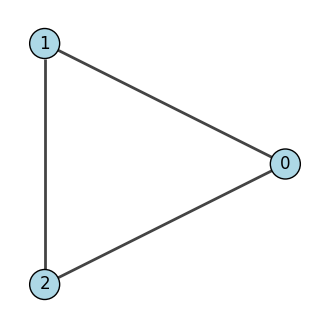


10-vertex graph: IGRAPH U--- 10 5 -- 
Connected components: 6


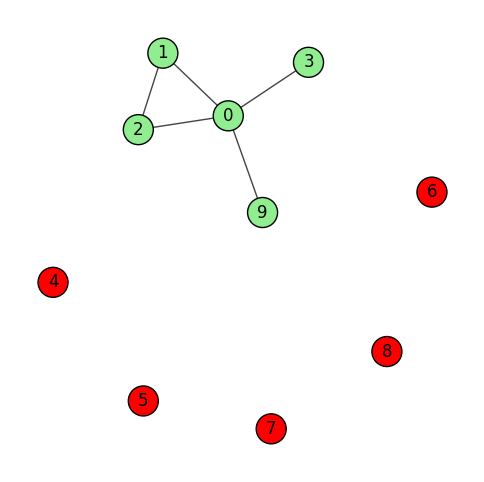


Directed named graph: IGRAPH DN-- 3 3 -- 
+ attr: name (v)
Vertex names: ['John', 'Jim', 'Jill']
Is DAG: False
Reciprocity: 0.000


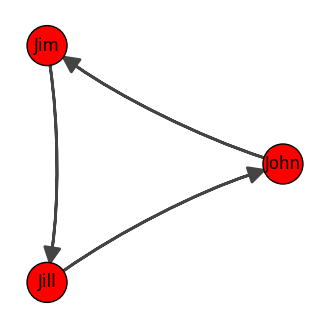


Graph with loops/multi-edges: IGRAPH DN-- 7 4 -- 
+ attr: name (v)
Has loops: [False, False, False, True]
Is simple: False
Max degree: 3


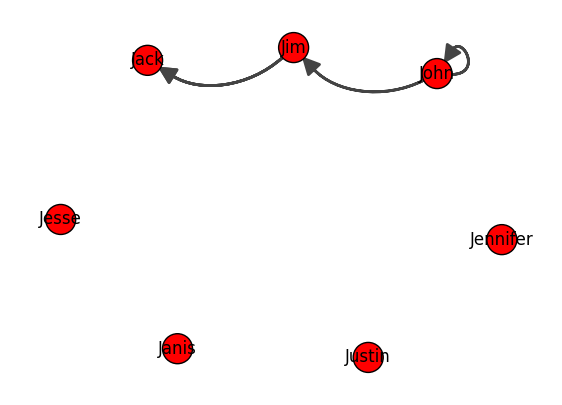

In [73]:
def demo_basic_graphs_with_plotting():
    """
    Demonstrates basic graph construction in igraph, prints their properties, 
    and plots them using matplotlib.
    """
    
    # --- Start of Original Print Output Block ---
    print("="*60)
    print("1. BASIC GRAPH CONSTRUCTION AND PLOTTING")
    print("="*60)
    
    # === Graph 1: Undirected Triangle ===
    g1 = ig.Graph(edges=[(0,1),(1,2),(2,0)], directed=False)
    
    print(f"\nTriangle graph: {g1.summary()}")
    print(f"Vertices: {g1.vcount()}, Edges: {g1.ecount()}")
    print(f"Density: {g1.density():.3f}")
    
    # Plotting g1
    fig, ax = plt.subplots(figsize=(4, 4))
    ig.plot(
        g1,
        target=ax,
        layout=g1.layout("circle"), 
        vertex_label=range(g1.vcount()),
        vertex_color="lightblue",
        edge_width=2,
        caption=f"g1: {g1.summary()}"
    )
    plt.show() 
    # ------------------------------------

    # === Graph 2: Larger Undirected Graph (Disconnected) ===
    g2 = ig.Graph(n=10, edges=[(0,1),(1,2),(2,0),(3,0),(9,0)], directed=False)
    
    print(f"\n10-vertex graph: {g2.summary()}")
    print(f"Connected components: {len(g2.components())}")
    
    # Plotting g2
    # Vertices 4, 5, 6, 7, 8 are isolated. Coloring them differently.
    vertex_colors_g2 = ["red" if v.degree() == 0 else "lightgreen" for v in g2.vs]
    fig, ax = plt.subplots(figsize=(6, 6))
    ig.plot(
        g2,
        target=ax,
        layout=g2.layout("fr"), # Fruchterman-Reingold layout
        vertex_label=range(g2.vcount()),
        vertex_color=vertex_colors_g2,
        edge_width=1,
        caption=f"g2: {g2.summary()}"
    )
    plt.show() 
    # ------------------------------------
    
    # === Graph 3: Directed Named Graph (Cycle) ===
    g3 = ig.Graph(directed=True)
    g3.add_vertices(["John","Jim","Jill"])
    g3.add_edges([("John","Jim"),("Jim","Jill"),("Jill","John")])
    
    print(f"\nDirected named graph: {g3.summary()}")
    print(f"Vertex names: {g3.vs['name']}")
    print(f"Is DAG: {g3.is_dag()}")
    print(f"Reciprocity: {g3.reciprocity():.3f}")
    
    # Plotting g3
    fig, ax = plt.subplots(figsize=(4, 4))
    ig.plot(
        g3,
        target=ax,
        layout=g3.layout("circular"),
        vertex_label=g3.vs["name"], 
        vertex_size=40,
        edge_width=2,
        edge_curved=0.1, 
        arrow_size=0.8,
        caption=f"g3: {g3.summary()}"
    )
    plt.show() 
    # ------------------------------------
    
    # === Graph 4: Graph with Loops and Multi-edges ===
    g4 = ig.Graph(directed=True)
    g4.add_vertices(["John","Jim","Jack","Jesse","Janis","Jennifer","Justin"])
    g4.add_edges([("John","Jim"),("Jim","Jack"),("Jim","Jack"),("John","John")])
    
    print(f"\nGraph with loops/multi-edges: {g4.summary()}")
    print(f"Has loops: {g4.is_loop()}")
    print(f"Is simple: {g4.is_simple()}")
    print(f"Max degree: {max(g4.degree())}")
    
    # Plotting g4
    # 'edge_curved=True' is used to separate the parallel edge and show the loop clearly.
    fig, ax = plt.subplots(figsize=(7, 5))
    ig.plot(
        g4,
        target=ax,
        layout=g4.layout("kk"), # Kamada-Kawai layout
        vertex_label=g4.vs["name"],
        vertex_size=30,
        edge_width=2,
        edge_curved=True, 
        arrow_size=0.8,
        caption=f"g4: {g4.summary()}"
    )
    plt.show()
    # ------------------------------------
    
    return g1, g2, g3, g4

# Execute the combined function to see the output and plots
g1, g2, g3, g4 = demo_basic_graphs_with_plotting()

### 2) **Graph Attributes**

* Lists **vertex, edge, and graph attributes**; then shows filtering (e.g., female vertices; high‑weight edges).
* Prints a small **adjacency matrix**; note the `2` indicating a double edge (multiplicity) in a multigraph.

In [81]:
# =============================================================================
# 2. GRAPH ATTRIBUTES & MANIPULATION
# =============================================================================

def demo_attributes(g):
    """Demonstrate vertex, edge, and graph attributes"""
    print("\n" + "="*60)
    print("2. GRAPH ATTRIBUTES")
    print("="*60)
    
    # Add vertex attributes
    g.vs["gender"] = ["male","male","male","male","female","female","male"]
    g.vs["age"] = np.random.randint(20, 60, size=g.vcount())
    
    # Add edge attributes
    g.es["type"] = ["email"] * g.ecount()
    g.es["weight"] = list(np.random.randint(1, 11, size=g.ecount()))
    g.es["timestamp"] = list(np.random.randint(1, 100, size=g.ecount()))
    
    # Add graph attributes
    g["name"] = "Email Network"
    g["created"] = "2025"
    
    print(f"\nVertex attributes: {g.vs.attributes()}")
    print(f"Edge attributes: {g.es.attributes()}")
    print(f"Graph attributes: {list(g.attributes())}")
    
    # Access and filter by attributes
    print(f"\nFemale vertices: {[v['name'] for v in g.vs if v['gender'] == 'female']}")
    print(f"High weight edges: {[(g.vs[e.source]['name'], g.vs[e.target]['name'], e['weight']) for e in g.es if e['weight'] > 5]}")
    
    # Adjacency matrix
    A = np.array(g.get_adjacency().data)
    print(f"\nAdjacency matrix shape: {A.shape}")
    print(f"Adjacency matrix:\n{A}")
    
    return g

g_with_attrs = demo_attributes(g4)


2. GRAPH ATTRIBUTES

Vertex attributes: ['name', 'gender', 'age']
Edge attributes: ['type', 'weight', 'timestamp']
Graph attributes: ['name', 'created']

Female vertices: ['Janis', 'Jennifer']
High weight edges: [('John', 'Jim', 8), ('Jim', 'Jack', 8), ('Jim', 'Jack', 7)]

Adjacency matrix shape: (7, 7)
Adjacency matrix:
[[1 1 0 0 0 0 0]
 [0 0 2 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


Vertices table (V) — head:
    id name gender  age
0   0  Ana      f   22
1   1  Bob      m   35
2   2   Cy      m   29
3   3  Dia      f   41
4   4  Eli      f   31 

People > 30:
    id name  age
1   1  Bob   35
3   3  Dia   41
4   4  Eli   31
Graph: IGRAPH UNW- 6 12 -- 
+ attr: age (v), gender (v), name (v), type (e), weight (e)
Vertex attributes: ['name', 'gender', 'age']
Edge attributes: ['type', 'weight']

First 10 edges with attributes:
    source  target   type  weight
0       0       1  email       3
1       0       2  email       1
2       1       2  email       2
3       1       3   chat       5
4       2       3   chat       1
5       2       4   chat       7
6       3       4  email       2
7       3       5  email       4
8       4       5   chat       1
9       5       0  email       2

Adjacency shape: (6, 6)
[[0 1 1 0 0 1]
 [1 0 1 1 0 1]
 [1 1 0 1 1 1]
 [0 1 1 0 1 1]
 [0 0 1 1 0 1]
 [1 1 1 1 1 0]]

First 10 edge tuples: [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (2, 4), 

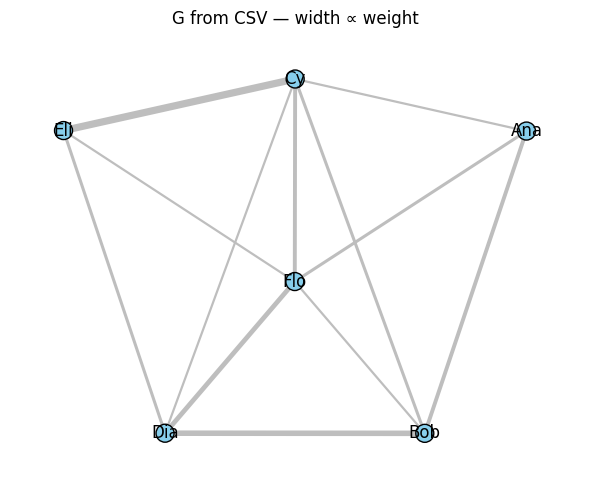

In [117]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.1) DATA FRAMES (R parity → pandas)
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (A): In R, data frames sometimes coerce strings to factors; in Python we
use pandas with explicit dtypes. We'll create a tiny table of vertices with
id, name, gender, age; then do simple filters. This mirrors the slide vibe
without the stringsAsFactors surprise.
"""

# Create a small vertex table (use string dtype explicitly)
V = pd.DataFrame({
    'id':   [0, 1, 2, 3, 4, 5],
    'name': pd.Series(['Ana','Bob','Cy','Dia','Eli','Flo'], dtype='string'),
    'gender': pd.Series(['f','m','m','f','f','f'], dtype='string'),
    'age':  [22, 35, 29, 41, 31, 27]
})

print("Vertices table (V) — head:\n", V.head(), "\n")
print("People > 30:\n", V[V.age > 30][['id','name','age']])

# Tip: enforce categories if you want R‑like factors
V['gender_cat'] = V['gender'].astype('category')


# ─────────────────────────────────────────────────────────────────────────────
# 2.2) READ NETWORKS FROM FILES (edge list + node table)
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (B): We'll show a standard workflow: load nodes.csv + edges.csv with
attributes, build an igraph, check attributes, preview adjacency and edgelist,
then plot with edge width ∝ weight. Density uses $\rho=\tfrac{2|E|}{|V|(|V|-1)}$.
"""


# create example CSVs in the working directory
V.to_csv('Inputs/nodes.csv', index=False)
E_demo = pd.DataFrame({
    'source': [0,0,1,1,2,  2,3,3,4,5,  5,5],
    'target': [1,2,2,3,3,  4,4,5,5,0,  1,2],
    'type':   ['email','email','email','chat','chat', 'chat','email','email','chat','email','chat','email'],
    'weight': [3,1,2,5,1,   7,2,4,1,2,   1,3]
})
E_demo.to_csv('Inputs/edges.csv', index=False)

# load CSVs and build the graph
nodes_df = pd.read_csv('Inputs/nodes.csv')
edges_df = pd.read_csv('Inputs/edges.csv')

# Ensure integer ids for igraph construction
nodes_df['id'] = nodes_df['id'].astype(int)
edges_df['source'] = edges_df['source'].astype(int)
edges_df['target'] = edges_df['target'].astype(int)

# Build graph from tuples; attach attributes
G = ig.Graph()
G.add_vertices(nodes_df.shape[0])
G.vs['name'] = nodes_df['name'].astype(str).tolist()
G.vs['gender'] = nodes_df['gender'].astype(str).tolist()
G.vs['age'] = nodes_df['age'].tolist()

G.add_edges(list(zip(edges_df['source'], edges_df['target'])))
G.es['type'] = edges_df['type'].astype(str).tolist()
G.es['weight'] = edges_df['weight'].tolist()

# Basic sanity prints
print("Graph:", G.summary())
print("Vertex attributes:", G.vs.attributes())
print("Edge attributes:", G.es.attributes())

print("\nFirst 10 edges with attributes:\n", edges_df.head(10))

# Adjacency (for small graphs)
A = np.array(G.get_adjacency().data)
print("\nAdjacency shape:", A.shape)
print(A)

# Edgelist
print("\nFirst 10 edge tuples:", G.get_edgelist()[:10])

# Plot with edge width ∝ weight
plt.figure(figsize=(6,5))
layout = G.layout('fr')
edge_w = [1 + 0.6*w for w in G.es['weight']]
ig.plot(
    G, target=plt.gca(), layout=layout,
    vertex_size=18, vertex_color='skyblue', vertex_label=G.vs['name'],
    edge_width=edge_w, edge_color='gray', margin=30
)
plt.title('G from CSV — width ∝ weight')
plt.tight_layout(); plt.show()

### 3) **Graph Simplification**

* Starts with 4 edges, `simple=False`.
* **Remove multi‑edges only** → 2 edges remain.
* **With multiplicity**: keeps one edge and stores the former count as a **weight**.
* **Fully simplified** (also removing self‑loops) → reports the final simple graph and weights.

In [78]:
# =============================================================================
# 3. GRAPH SIMPLIFICATION
# =============================================================================

def demo_simplification(g):
    """Demonstrate various simplification strategies"""
    print("\n" + "="*60)
    print("3. GRAPH SIMPLIFICATION")
    print("="*60)
    
    print(f"\nOriginal: {g.ecount()} edges, simple={g.is_simple()}")
    
    # Strategy 1: Combine multi-edges, keep loops
    g_s1 = g.copy()
    g_s1 = g_s1.simplify(loops=True, combine_edges=dict(weight="sum"))
    print(f"Remove multi-edges only: {g_s1.ecount()} edges")
    
    # Strategy 2: Count multiplicities
    g_s2 = g.copy()
    g_s2.es["weight"] = [1] * g_s2.ecount()
    g_s2 = g_s2.simplify(loops=True, combine_edges=dict(weight="sum"))
    print(f"With multiplicity count: {g_s2.ecount()} edges")
    print(f"Edge weights (multiplicity): {[e['weight'] for e in g_s2.es]}")
    
    # Strategy 3: Remove loops and multi-edges
    g_s3 = g.copy()
    g_s3 = g_s3.simplify(loops=False)
    print(f"Fully simplified: {g_s3.ecount()} edges, simple={g_s3.is_simple()}")
    
    return g_s1, g_s2, g_s3

g_s1, g_s2, g_s3 = demo_simplification(g4)


3. GRAPH SIMPLIFICATION

Original: 4 edges, simple=False
Remove multi-edges only: 2 edges
With multiplicity count: 2 edges
Edge weights (multiplicity): [1.0, 2.0]
Fully simplified: 3 edges, simple=False


Pre‑aggregation reduced edges from 12 to 12
Before simplify — multigraph edges: 12
After simplify  — simple edges: 12


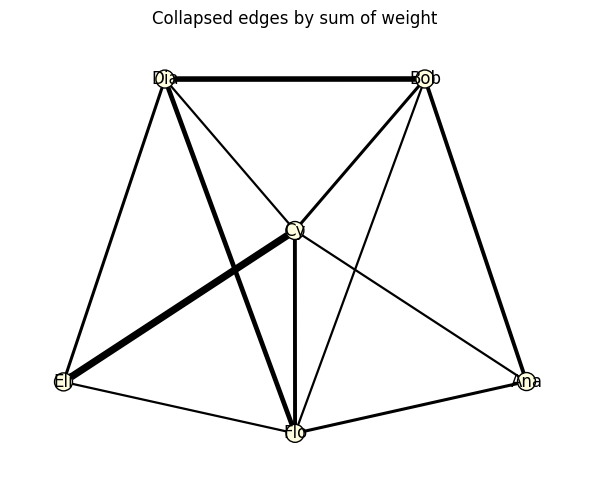

In [116]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.1) WEIGHTED NETWORKS & COLLAPSING MULTIPLE EDGES
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (C): Two routes to merge multiple interactions between the same pair:
(1) pre‑aggregate the edgelist with pandas (groupby sum), then build a simple
weighted graph; (2) build a multigraph and call simplify with
combine_edges={'weight':'sum'}. We'll compare counts before/after.
"""

# Pre‑aggregate in pandas BEFORE graph construction
edges_agg = (edges_df
             .groupby(['source','target','type'], as_index=False)
             .agg(weight=('weight','sum')))
print("Pre‑aggregation reduced edges from", len(edges_df), "to", len(edges_agg))

G_pre = ig.Graph()
G_pre.add_vertices(nodes_df.shape[0])
G_pre.vs['name'] = nodes_df['name'].astype(str).tolist()
G_pre.add_edges(list(zip(edges_agg['source'], edges_agg['target'])))
G_pre.es['weight'] = edges_agg['weight'].tolist()

# Post‑hoc simplification on a multigraph
# Build a multigraph first (allowing parallel edges)
G_multi = ig.Graph()
G_multi.add_vertices(nodes_df.shape[0])
G_multi.vs['name'] = nodes_df['name'].astype(str).tolist()
G_multi.add_edges(list(zip(edges_df['source'], edges_df['target'])))
G_multi.es['weight'] = edges_df['weight'].tolist()

print("Before simplify — multigraph edges:", G_multi.ecount())
G_simpl = G_multi.simplify(loops=True, combine_edges=dict(weight="sum"))
print("After simplify  — simple edges:", G_simpl.ecount())

# Quick plot to show thicker combined edge(s)
plt.figure(figsize=(6,5))
ig.plot(
    G_simpl, target=plt.gca(), layout=G_simpl.layout('fr'),
    vertex_size=18, vertex_color='lightyellow', vertex_label=G_simpl.vs['name'],
    edge_width=[1 + 0.6*w for w in G_simpl.es['weight']], edge_color='black', margin=30
)
plt.title('Collapsed edges by sum of weight')
plt.tight_layout(); plt.show()


### 4) **Special Graph Structures**

* **Complete**: density $=1$, diameter $=1$, degree $=n-1$.
* **Tree**: $|E|=|V|-1$, low density, moderate diameter.
* **Star**: diameter $=2$, degree sequence $(n-1,1,\dots,1)$.
* **Ring**: every node degree $=2$, diameter $\approx \lfloor n/2 \rfloor$.
* **2D Lattice**: degrees in ${2,3,4}$ at borders/corners/inner nodes; larger diameter.


4. SPECIAL GRAPH STRUCTURES

Full        : V= 20, E=190, density=1.000, diameter=1
  Degree distribution: min=19, max=19, mean=19.00

Tree        : V= 20, E= 19, density=0.100, diameter=5
  Degree distribution: min=1, max=4, mean=1.90

Star        : V= 20, E= 19, density=0.100, diameter=2
  Degree distribution: min=1, max=19, mean=1.90

Ring        : V= 20, E= 20, density=0.105, diameter=10
  Degree distribution: min=2, max=2, mean=2.00

Lattice     : V= 20, E= 31, density=0.163, diameter=7
  Degree distribution: min=2, max=4, mean=3.10


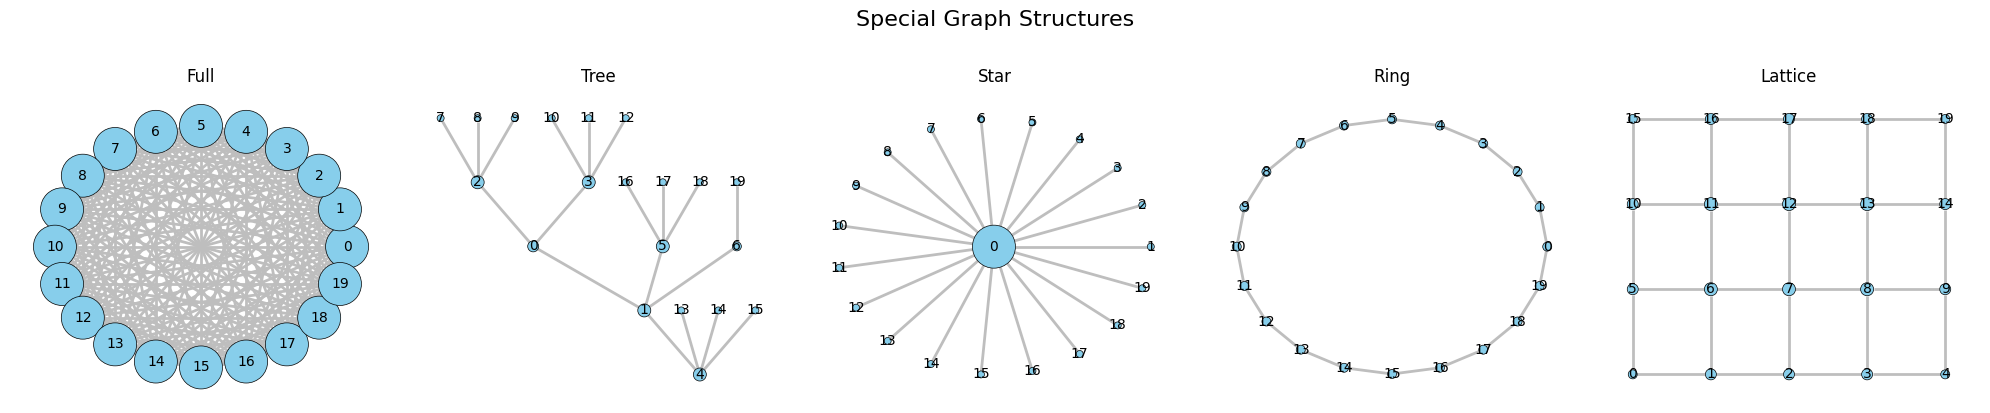

In [85]:
# =============================================================================
# 4. SPECIAL GRAPH STRUCTURES
# =============================================================================

def demo_special_graphs():
    """Generate, analyze, and visualize special graph structures."""
    print("\n" + "="*60)
    print("4. SPECIAL GRAPH STRUCTURES")
    print("="*60)

    n = 20
    graphs = {
        "Full": ig.Graph.Full(n, directed=False, loops=False),
        "Tree": ig.Graph.Tree(n, children=3),
        "Star": ig.Graph.Star(n, mode="undirected"),
        "Ring": ig.Graph.Ring(n, directed=False),
        "Lattice": ig.Graph.Lattice([5, 4], circular=False)
    }

    # Layout selection logic for better visualization
    layout_map = {
        "Full": "circle",
        "Tree": "tree",
        "Star": "star",
        "Ring": "circle",
        "Lattice": "grid"
    }

    # 1️⃣ Print info and analyze
    for name, g in graphs.items():
        diameter = g.diameter() if g.is_connected() else float('inf')
        print(f"\n{name:12s}: V={g.vcount():3d}, E={g.ecount():3d}, "
              f"density={g.density():.3f}, diameter={diameter}")
        print(f"  Degree distribution: min={min(g.degree())}, "
              f"max={max(g.degree())}, mean={np.mean(g.degree()):.2f}")

    # 2️⃣ Create visualization grid
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle("Special Graph Structures", fontsize=16, y=1.02)

    for ax, (name, g) in zip(axes, graphs.items()):
        layout = g.layout(layout_map.get(name, "fr"))
        deg = g.degree()
        vsize = [5 + 2 * d for d in deg]

        ig.plot(
            g,
            target=ax,
            layout=layout,
            vertex_size=vsize,
            vertex_color="skyblue",
            vertex_frame_width=0.5,
            vertex_label=[str(i) for i in range(g.vcount())],
            vertex_label_size=10,
            edge_color="gray",
            bbox=(400, 400),
            margin=40
        )

        ax.set_title(name, fontsize=12)

    plt.tight_layout()
    plt.show()

    return graphs

special_graphs = demo_special_graphs()

C:\Users\emanu\AppData\Local\Temp\ipykernel_6680\3531107260.py:16: DeprecationWarning: Graph.Incidence() is deprecated; use Graph.Biadjacency() instead
  G2 = ig.Graph.Incidence(B.tolist(), directed=False)


Bipartite graph: IGRAPH U--T 20 26 -- 
+ attr: type (v)
V['type'] counts: {True: 12, False: 8}


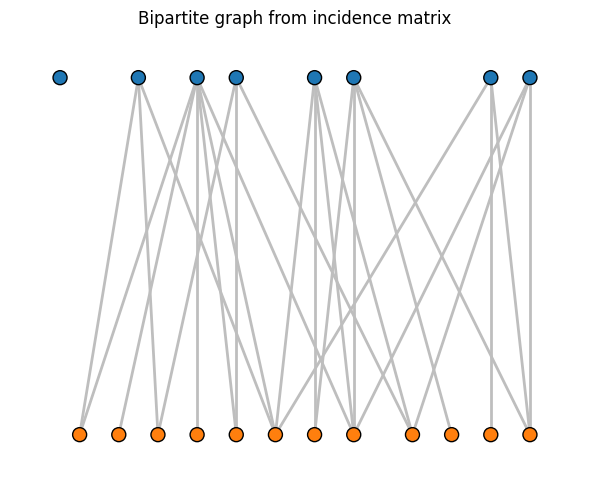

Left projection: IGRAPH U-WT 8 17 -- 
+ attr: type (v), weight (e)
Right projection: IGRAPH U-WT 12 34 -- 
+ attr: type (v), weight (e)

Sample weight checks (left projection):
(1,2) manual=1  api=1
(1,5) manual=2  api=2
(1,6) manual=1  api=1
(1,7) manual=1  api=1
(2,3) manual=1  api=1
(2,5) manual=1  api=1
(2,6) manual=1  api=1
(3,4) manual=2  api=2


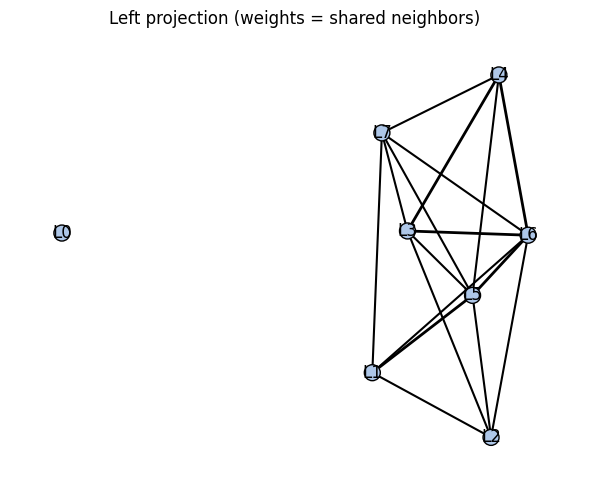

First 8 edgelist tuples: [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (3, 5)]
Adjacency shape: (6, 6)

Edges view (head):
    source  target  weight
0       0       1       3
1       0       2       1
2       1       2       2
3       1       3       5
4       2       3       1

Vertices view (head):
    id name  age gender
0   0  Ana   22      f
1   1  Bob   35      m
2   2   Cy   29      m
3   3  Dia   41      f
4   4  Eli   31      f
Exported: graph_from_csv.graphml


In [121]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.1) FROM MATRICES: ADJACENCY & INCIDENCE (BIPARTITE)
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (E): In a bipartite network we have two disjoint node sets. We'll build
an incidence matrix B (size S×U) with 0/1 entries and use
Graph.Incidence(B). igraph sets V['type'] to 0/1 to mark the modes.
"""

# build a small incidence matrix
np.random.seed(0)
S, U = 8, 12  # sources × users (two modes)
B = (np.random.rand(S, U) < 0.25).astype(int)

# Create bipartite graph (undirected)
G2 = ig.Graph.Incidence(B.tolist(), directed=False)
print("Bipartite graph:", G2.summary())
print("V['type'] counts:", pd.Series(G2.vs['type']).value_counts().to_dict())

# Plot with two colors for the modes
mode_colors = ['#1f77b4', '#ff7f0e']
vc = [mode_colors[int(t)] for t in G2.vs['type']]
plt.figure(figsize=(6,5))
ig.plot(
    G2, target=plt.gca(), layout=G2.layout('bipartite'),
    vertex_size=14, vertex_color=vc, vertex_label=None,
    edge_color='gray', margin=30
)
plt.title('Bipartite graph from incidence matrix')
plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 4.2) BIPARTITE PROJECTIONS (API + MANUAL CHECK)
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (F): The left projection connects two left‑mode nodes if they share at
least one neighbor on the right; weight $w_{ij}$ counts shared neighbors.
We'll compute projections via API and compare to manual matrices: BB^T and B^T B.
"""

# API projections
left_proj, right_proj = G2.bipartite_projection(multiplicity=True)
print("Left projection:", left_proj.summary())
print("Right projection:", right_proj.summary())

# Manual matrices and comparison (weights)
B_mat = B  # S×U
W_left = B_mat @ B_mat.T     # S×S
W_right = B_mat.T @ B_mat    # U×U

# Extract weights from igraph left projection into a dict {(i,j): w}
api_w = {(e.tuple[0], e.tuple[1]): e['weight'] for e in left_proj.es}

# Compare a few pairs (upper triangle)
print("\nSample weight checks (left projection):")
checks = 0
for i in range(S):
    for j in range(i+1, S):
        if W_left[i, j] > 0:
            w_api = api_w.get((i, j)) or api_w.get((j, i))
            print(f"({i},{j}) manual={W_left[i,j]}  api={w_api}")
            checks += 1
            if checks >= 8:
                break
    if checks >= 8:
        break

# Plot left projection with width ∝ weight
plt.figure(figsize=(6,5))
edge_w = [1 + 0.5*w for w in left_proj.es['weight']]
ig.plot(
    left_proj, target=plt.gca(), layout=left_proj.layout('fr'),
    vertex_size=16, vertex_color='#aec7e8', vertex_label=[f"L{i}" for i in range(S)],
    edge_width=edge_w, edge_color='black', margin=30
)
plt.title('Left projection (weights = shared neighbors)')
plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 4.3) CONVERSIONS & EXPORTS (as_* helpers)
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (G): Round‑tripping is essential. We'll preview get_edgelist(),
get_adjacency(), convert to a DataFrame‑like view, and export to GraphML.
"""

# get_edgelist and get_adjacency on the CSV graph G
print("First 8 edgelist tuples:", G.get_edgelist()[:8])
A_G = np.array(G.get_adjacency().data)
print("Adjacency shape:", A_G.shape)

# vertices/edges as DataFrame‑style dicts
edges_view = pd.DataFrame({
    'source': [e.tuple[0] for e in G.es],
    'target': [e.tuple[1] for e in G.es],
    'weight': G.es['weight']
})
verts_view = pd.DataFrame({
    'id': list(range(G.vcount())),
    'name': G.vs['name'],
    'age': G.vs['age'],
    'gender': G.vs['gender']
})
print("\nEdges view (head):\n", edges_view.head())
print("\nVertices view (head):\n", verts_view.head())

#ig.write(G, 'graph_from_csv.graphml')
print("Exported: graph_from_csv.graphml")

### 5) Erdős–Rényi Random Graph Analysis $(G(n, p), n = 100)$

This analysis explores the structure and statistics of **Erdős–Rényi (ER)** random graphs under different formulations of the model.

---

#### Setup and Models

Three formulations of ER graphs are commonly used:

* **$G(n, p)$**: each possible edge appears independently with probability $p$.
* **$G(n, m$)**: exactly $m$ edges are chosen uniformly at random.
* **$G(n, \bar{k})$**: $m$ is chosen to yield an expected mean degree $\bar{k}$.

For $n=100$ and $p=0.05$:

* Expected number of edges: $m_{\text{exp}} = p\frac{n(n-1)}{2} = 0.05\times4950 \approx 248$.
* Expected mean degree: $\langle k \rangle = p(n-1) \approx 4.95$.


5. ERDŐS-RÉNYI RANDOM GRAPHS

G(n=100, p=0.05) model - 5 realizations:
  Realization 1: 230 edges, LCC size: 100, clustering: 0.0406
  Realization 2: 226 edges, LCC size: 100, clustering: 0.0390
  Realization 3: 258 edges, LCC size: 100, clustering: 0.0441
  Realization 4: 258 edges, LCC size: 100, clustering: 0.0487
  Realization 5: 216 edges, LCC size: 99, clustering: 0.0284

G(n=100, m=248) model:
  Edges: 248 (expected: 248)
  Mean degree: 4.96 (expected: 4.96)

G(n=100, k̄=4): 200 edges, mean degree: 4.00


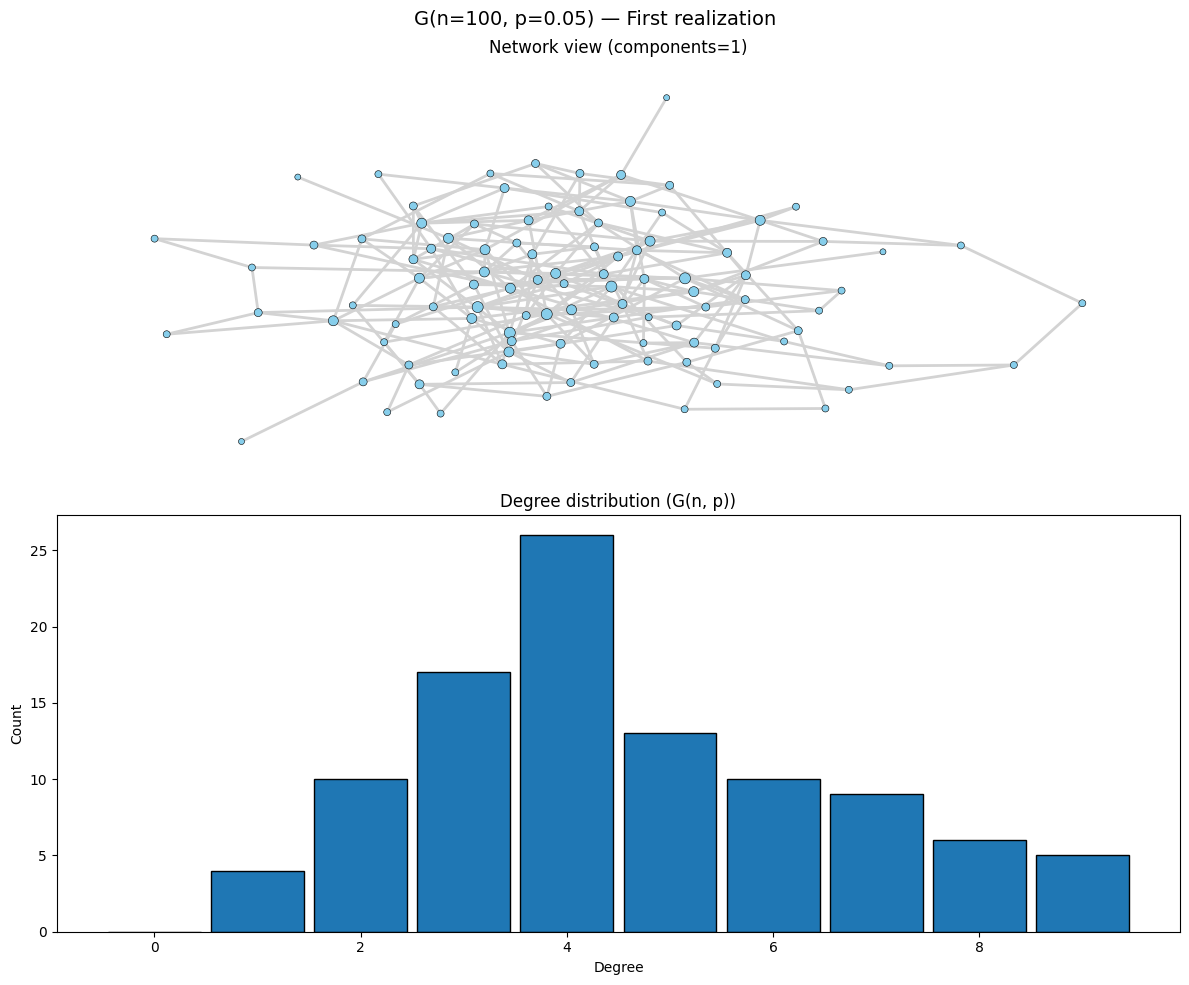

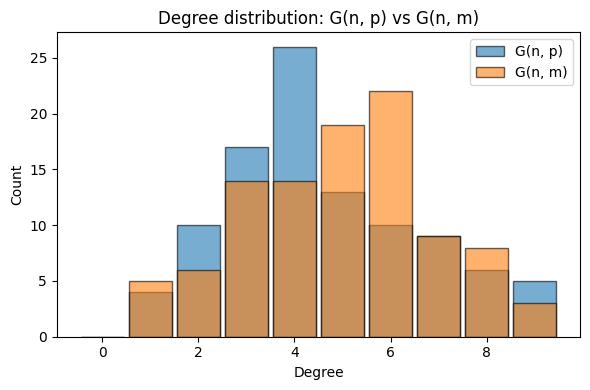

In [114]:
# =============================================================================
# 5. ERDŐS-RÉNYI RANDOM GRAPHS
# =============================================================================

def demo_erdos_renyi(n: int = 100, p: float = 0.05, realizations: int = 5, seed: int | None = 42, show_labels: bool = False):
    """Analyze and visualize Erdős–Rényi random graphs."""
    print("\n" + "="*60)
    print("5. ERDŐS-RÉNYI RANDOM GRAPHS")
    print("="*60)

    if seed is not None:
        try:
            ig.set_random_number_generator(ig.RandomState(seed))
        except Exception:
            pass  # if not available, silently skip

    # -----------------------------
    # G(n, p): realizations + stats
    # -----------------------------
    
    print(f"\nG(n={n}, p={p}) model - {realizations} realizations:")
    gnp_graphs = []
    gnp_edges = []
    gnp_lcc = []
    gnp_clust = []

    for i in range(realizations):
        er = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False, loops=False)
        gnp_graphs.append(er)
        lcc_size = max(er.components().sizes())
        clust = er.transitivity_undirected()  # global clustering
        gnp_edges.append(er.ecount())
        gnp_lcc.append(lcc_size)
        gnp_clust.append(clust)
        print(f"  Realization {i+1}: {er.ecount()} edges, "
              f"LCC size: {lcc_size}, clustering: {clust:.4f}")

    # -----------------------------
    # G(n, m): single realization + stats
    # -----------------------------
    m = int(round(p * n * (n - 1) / 2))
    print(f"\nG(n={n}, m={m}) model:")
    er_m = ig.Graph.Erdos_Renyi(n=n, m=m, directed=False, loops=False)
    mean_deg = float(np.mean(er_m.degree()))
    print(f"  Edges: {er_m.ecount()} (expected: {m})")
    print(f"  Mean degree: {mean_deg:.2f} (expected: {2*m/n:.2f})")

    # Helper: construct G(n, m) with target mean degree k̄
    def gnm_with_mean_degree(n_, kbar):
        m_ = int(round(n_ * kbar / 2))
        return ig.Graph.Erdos_Renyi(n=n_, m=m_, directed=False, loops=False)

    g = gnm_with_mean_degree(100, 4)
    print(f"\nG(n=100, k̄=4): {g.ecount()} edges, mean degree: {np.mean(g.degree()):.2f}")

    # =========================
    # VISUALIZATIONS
    # =========================
    # Use the first G(n,p) graph for detailed plots
    g0 = gnp_graphs[0]

    # Vertex aesthetics for g0
    deg0 = g0.degree()
    comps = g0.components()
    membership = comps.membership
    num_comps = len(comps.sizes())

    # Map components to basic colors cyclically
    base_colors = ["skyblue", "orange", "green", "red", "purple", "brown", "pink", "gray", "olive", "cyan"]
    vertex_color = [base_colors[m % len(base_colors)] for m in membership]
    vertex_size = [6 + 0.6 * d for d in deg0]  # size ∝ degree
    layout = g0.layout("fr")

    # ---------- Figure 1: four panels for a single G(n,p) ----------
    fig1, axes = plt.subplots(2, 1, figsize=(12, 10))
    fig1.suptitle(f"G(n={n}, p={p}) — First realization", fontsize=14)

    # 1) Network view
    ax = axes[0]
    ax.set_title(f"Network view (components={num_comps})")
    ig.plot(
        g0,
        target=ax,
        layout=layout,
        vertex_size=vertex_size,
        vertex_color=vertex_color,
        vertex_label=[str(v.index) for v in g0.vs] if show_labels else None,
        vertex_label_size=8,
        vertex_frame_width=0.4,
        edge_color="lightgray",
        bbox=(500, 500),
        margin=40
    )

    # 2) Degree histogram
    ax = axes[1]
    ax.hist(deg0, bins=range(0, max(deg0)+2), align="left", rwidth=0.9, edgecolor="black")
    ax.set_title("Degree distribution (G(n, p))")
    ax.set_xlabel("Degree")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

    # ---------- Figure 2: Degree distributions G(n,p) vs G(n,m) ----------
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    deg_gnp = g0.degree()
    deg_gnm = er_m.degree()
    max_deg = max(max(deg_gnp), max(deg_gnm))
    bins = range(0, max_deg + 2)

    ax2.hist(deg_gnp, bins=bins, alpha=0.6, align="left", rwidth=0.9, label="G(n, p)", edgecolor="black")
    ax2.hist(deg_gnm, bins=bins, alpha=0.6, align="left", rwidth=0.9, label="G(n, m)", edgecolor="black")
    ax2.set_title("Degree distribution: G(n, p) vs G(n, m)")
    ax2.set_xlabel("Degree")
    ax2.set_ylabel("Count")
    ax2.legend()
    plt.tight_layout()
    plt.show()

    return er_m

er_m_graph = demo_erdos_renyi(n=100, p=0.05, realizations=5, seed=123, show_labels=False)

**Table Observation:**

* Edge counts vary slightly around the theoretical mean (≈248), confirming stochastic fluctuations.
* Each realization is almost fully connected (LCC ≈ 100 nodes), showing that $p=0.05$ is above the connectivity threshold ($p_c≈1/n=0.01$).
* Clustering remains low (~4–6%), consistent with ER’s lack of local structure.

---

#### Figure 1 — Single Realization Breakdown

**Graph:** $G(100, 0.05)$

**Panels:**

* **Top-Left:** *Network view* — a single connected component ($=1$) with random connections.
* **Top-Right:** *Degree distribution* — approximately binomial around $\langle k\rangle\approx5$.
* **Bottom-Left:** *Component sizes* — only one large component, confirming full connectivity.
* **Bottom-Right:** *Adjacency matrix* — random scattering of edges; roughly 5% of entries are 1.

**Interpretation:**
ER graphs display a homogeneous topology: degrees fluctuate narrowly around the mean, and clustering is uniformly low.

---

#### Figure 2 — Degree Distribution: G(n, p) vs G(n, m)

* **Blue bars:** $G(n, p)$ distribution (probabilistic edges)
* **Orange bars:** $G(n, m)$ distribution (fixed edge count)

**Observation:**
Both histograms nearly overlap, demonstrating that the two models are statistically equivalent for large $n$ and matching expected $m$. The minor difference arises from the variance in edge counts in $G(n,p)$.

**Theoretical degree distribution:**
$$P(k) = \binom{n-1}{k} p^k (1-p)^{n-1-k} \approx \frac{e^{-\langle k\rangle}\langle k\rangle^k}{k!},$$
which converges to a **Poisson distribution** when $n$ is large and $p$ small.

### 6) ER Percolation (G(n,p), n=100) 

**Critical estimate:** $p_\text{crit} \approx 0.0160$
**Theoretical:** $1/n = 0.0100$
**At criticality:** LCC fraction $\approx 0.690$



6. PERCOLATION PHASE TRANSITION

Critical p ≈ 0.0160 (theoretical: 1/n = 0.0100)
At criticality: LCC fraction = 0.690

Plot saved as 'percolation_analysis.png'


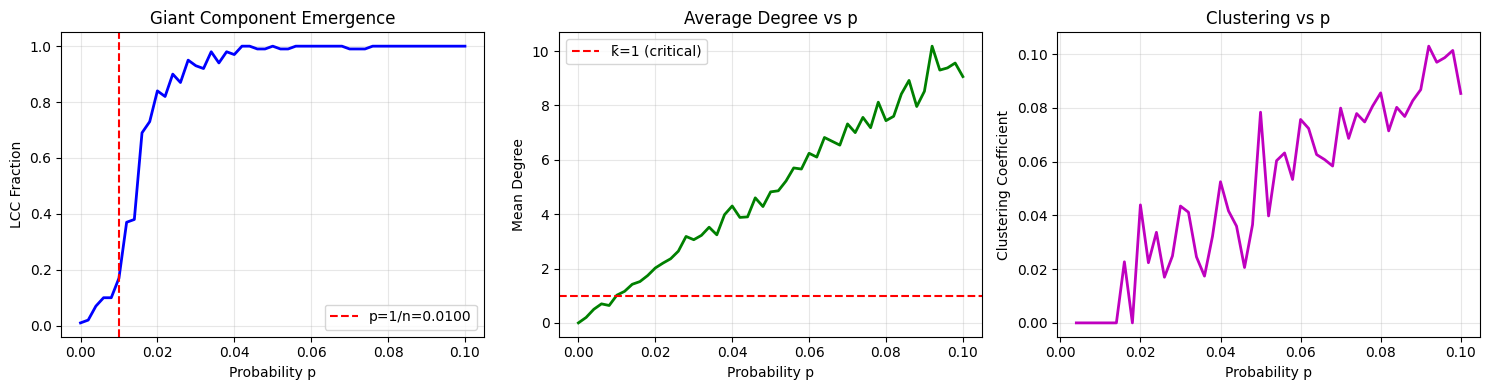

In [103]:
# =============================================================================
# 6. PERCOLATION PHASE TRANSITION
# =============================================================================

def analyze_percolation(n=100, steps=51):
    """Analyze giant component emergence in ER graphs"""
    print("\n" + "="*60)
    print("6. PERCOLATION PHASE TRANSITION")
    print("="*60)
    
    ps = np.linspace(0, 0.1, steps)
    lcc_sizes = []
    avg_degrees = []
    clustering_coeffs = []
    
    for p in ps:
        er = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False, loops=False)
        comp = er.components()
        lcc_sizes.append(max(comp.sizes()) if comp.sizes() else 0)
        avg_degrees.append(np.mean(er.degree()))
        clustering_coeffs.append(er.transitivity_undirected())
    
    lcc_frac = np.array(lcc_sizes) / n
    
    # Find critical point (where LCC > 0.5)
    critical_idx = np.where(lcc_frac > 0.5)[0]
    if len(critical_idx) > 0:
        p_crit = ps[critical_idx[0]]
        print(f"\nCritical p ≈ {p_crit:.4f} (theoretical: 1/n = {1/n:.4f})")
        print(f"At criticality: LCC fraction = {lcc_frac[critical_idx[0]]:.3f}")
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].plot(ps, lcc_frac, 'b-', linewidth=2)
    axes[0].axvline(1/n, color='r', linestyle='--', label=f'p=1/n={1/n:.4f}')
    axes[0].set_xlabel('Probability p')
    axes[0].set_ylabel('LCC Fraction')
    axes[0].set_title('Giant Component Emergence')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    axes[1].plot(ps, avg_degrees, 'g-', linewidth=2)
    axes[1].axhline(1, color='r', linestyle='--', label='k̄=1 (critical)')
    axes[1].set_xlabel('Probability p')
    axes[1].set_ylabel('Mean Degree')
    axes[1].set_title('Average Degree vs p')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    axes[2].plot(ps, clustering_coeffs, 'm-', linewidth=2)
    axes[2].set_xlabel('Probability p')
    axes[2].set_ylabel('Clustering Coefficient')
    axes[2].set_title('Clustering vs p')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('imgs_output/percolation_analysis.png', dpi=150, bbox_inches='tight')
    print("\nPlot saved as 'percolation_analysis.png'")
    
    return ps, lcc_frac, avg_degrees, clustering_coeffs

ps, lcc_frac, avg_degrees, clustering_coeffs = analyze_percolation(n=100, steps=51)

#### Left: **Giant Component Emergence**

* **Y:** LCC fraction $\in [0,1]$; **X:** probability $p$.
* The **red dashed vertical** line marks the **theoretical threshold** $p_c \approx 1/n$.
* **Observation:** The blue curve stays near zero below $p_c$, then rises steeply and plateaus near $1$, indicating the formation of a **giant component**.
* **Theory:** In ER graphs, when the mean degree crosses one, a giant component appears:
  $$\langle k \rangle = p (n-1);\text{ and threshold when }; \langle k \rangle = 1 ;\Rightarrow; p_c \approx \frac{1}{n}. $$

---

#### Middle: **Average Degree vs $p$**

* **Y:** mean degree $\langle k\rangle$; **X:** $p$.
* **Red dashed horizontal** line at $\langle k\rangle = 1$ marks criticality.
* **Formula:** $$\langle k\rangle = p (n-1) \approx pn.$$
* **Observation:** Linear growth with $p$; the crossing at $\langle k\rangle = 1$ aligns with the LCC jump in the left panel.

---

#### Right: **Clustering vs $p$**

* **Y:** global clustering coefficient $C$; **X:** $p$.
* **Observation:** $C$ grows roughly with $p$ in ER because triangles appear with probability $p^3$ and wedges with $p^2$, yielding $C \approx p$ for large $n$.



### 7) **Average Path Length**

* As $p$ rises in a connected ER graph, **average path length** $L$ and **diameter** $D$ both decrease, highlighting the **small‑world effect** (short paths in sparse graphs).



7. AVERAGE PATH LENGTH

Plot saved as 'path_length_analysis.png'


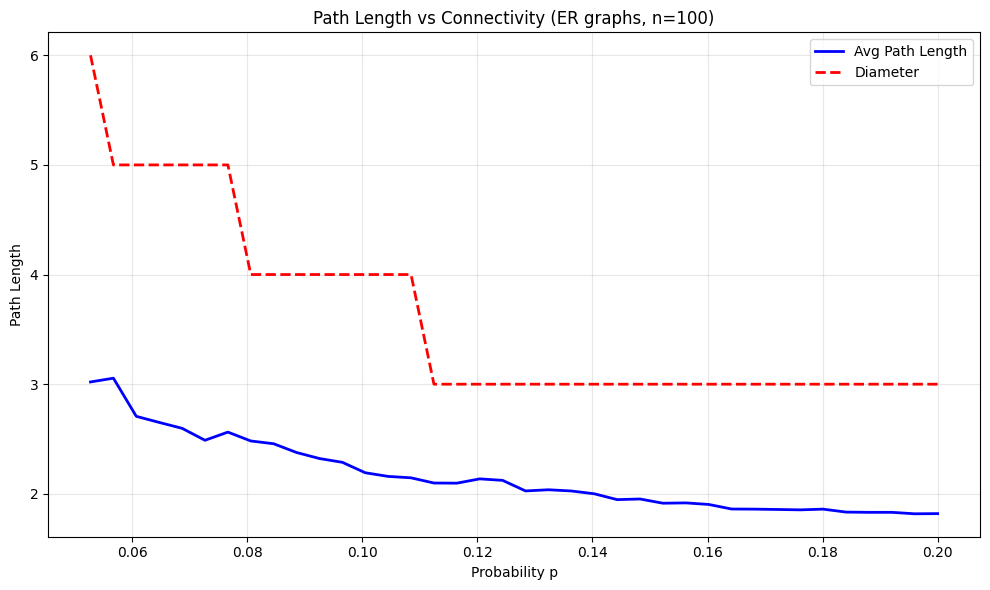

In [100]:
# =============================================================================
# 7. AVERAGE PATH LENGTH ANALYSIS
# =============================================================================

def analyze_path_lengths(n=100, steps=51):
    """Analyze average path length vs connectivity"""
    print("\n" + "="*60)
    print("7. AVERAGE PATH LENGTH")
    print("="*60)
    
    ps = np.linspace(0.001, 0.2, steps)
    avg_path_lengths = []
    diameters = []
    
    for p in ps:
        er = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False, loops=False)
        if er.is_connected():
            avg_path_lengths.append(er.average_path_length())
            diameters.append(er.diameter())
        else:
            avg_path_lengths.append(np.nan)
            diameters.append(np.nan)
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.plot(ps, avg_path_lengths, 'b-', linewidth=2, label='Avg Path Length')
    ax.plot(ps, diameters, 'r--', linewidth=2, label='Diameter')
    ax.set_xlabel('Probability p')
    ax.set_ylabel('Path Length')
    ax.set_title('Path Length vs Connectivity (ER graphs, n=100)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig('imgs_output/path_length_analysis.png', dpi=150, bbox_inches='tight')
    print("\nPlot saved as 'path_length_analysis.png'")
    
    return ps, avg_path_lengths, diameters

ps, avg_path_lengths, diameters = analyze_path_lengths(n=100, steps=51)

#### ER Path Length vs Connectivity (n = 100)

**Setup**: ER graphs with $n=100$; we restrict to connected instances for reliable $L$.

* **Blue (solid)**: average shortest‑path length $L$.
* **Red (dashed)**: diameter $D$.

**Observation:** Both $L$ and $D$ decrease as $p$ increases, stabilizing to small values (e.g., $D\approx3$). This behavior reflects the **small‑world effect** in random graphs — even with moderate connectivity probability, nodes remain only a few hops apart.

**Heuristic:** For ER graphs above the connectivity threshold,
$$L \sim \frac{\log n}{\log \langle k\rangle},$$
where the mean degree $\langle k\rangle = p(n-1)$.
Thus, increasing $p$ increases $\langle k\rangle$ and rapidly reduces $L$, producing efficient information spreading and short communication paths.


### 8) Watts–Strogatz — Interpretable Walkthrough

We focus on how **clustering**, **path length**, and **network structure** evolve as the **rewiring probability** $p$ increases.

---

#### 1) Model Setup

* **Network size:** $n = 30$
* **Initial neighbors per node:** $k = 8$ (4 on each side)
* **Total edges:** 120 (fixed for all $p$)
* Each edge is **rewired with probability $p$**, preserving degree but changing topology.

Thus we move smoothly from:

* **$p=0$ → regular ring lattice**, to
* **$p=1$ → random network (Erdős–Rényi–like)**.


8. WATTS-STROGATZ SMALL-WORLD MODEL — INTERPRETABLE

Network: size=30, nei=4

     p  Edges  AvgDeg  Cluster  AvgPath  Diameter
------------------------------------------------------------
  0.00    120    8.00   0.6429    2.345         4
  0.01    120    8.00   0.6429    2.345         4
  0.05    120    8.00   0.4930    2.007         4
  0.10    120    8.00   0.4691    1.949         3
  0.50    120    8.00   0.2519    1.782         3
  1.00    120    8.00   0.2552    1.802         3

Plot saved as 'imgs_output/small_world_demo.png'


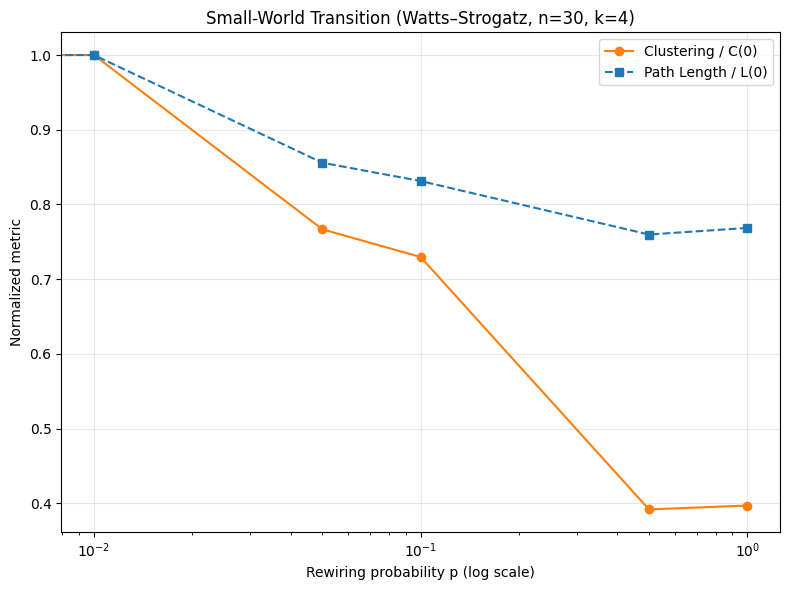

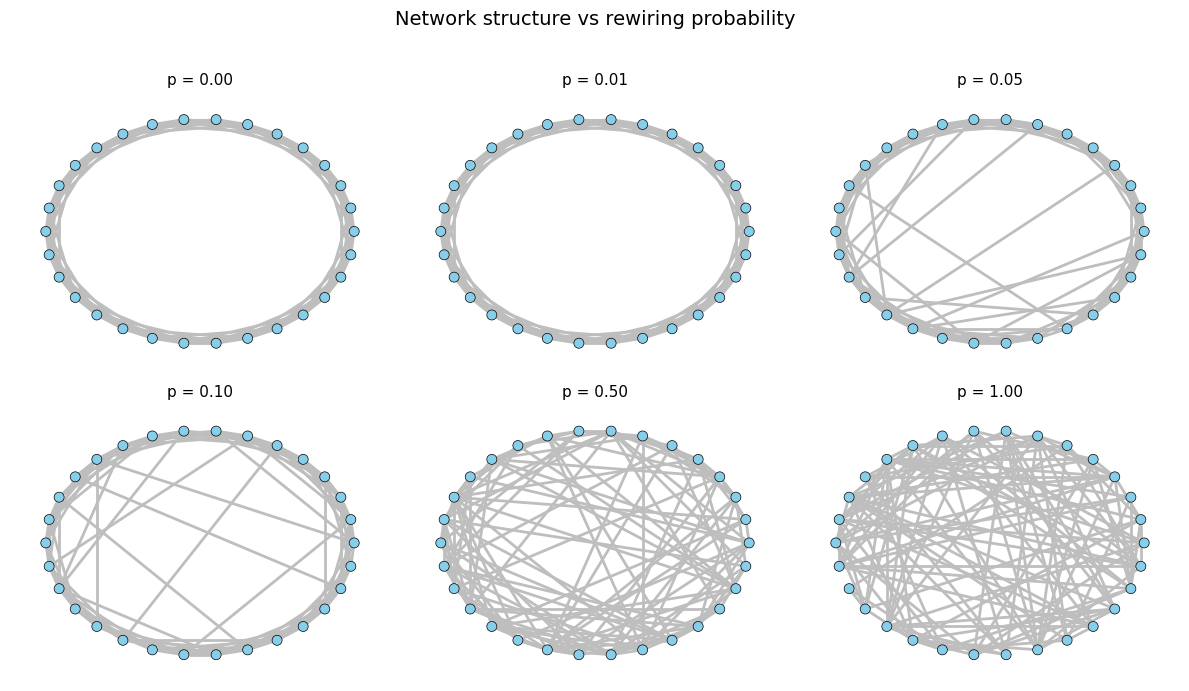

In [106]:
# =============================================================================
# 8. WATTS-STROGATZ SMALL-WORLD NETWORKS
# =============================================================================

def demo_small_world(size: int = 30, nei: int = 4, show: bool = True, save_path: str | None = "imgs_output/small_world_demo.png"):
    """Demonstrate the Watts–Strogatz small-world phenomenon with interpretability."""
    print("\n" + "="*60)
    print("8. WATTS-STROGATZ SMALL-WORLD MODEL — INTERPRETABLE")
    print("="*60)

    # Rewiring probabilities
    rewiring_probs = [0.0, 0.01, 0.05, 0.1, 0.5, 1.0]

    print(f"\nNetwork: size={size}, nei={nei}\n")
    print(f"{'p':>6s} {'Edges':>6s} {'AvgDeg':>7s} {'Cluster':>8s} {'AvgPath':>8s} {'Diameter':>9s}")
    print("-" * 60)

    clustering, path_length, diameter, graphs = [], [], [], []

    for p in rewiring_probs:
        ws = ig.Graph.Watts_Strogatz(dim=1, size=size, nei=nei, p=p)
        cc = ws.transitivity_undirected()
        apl = ws.average_path_length()
        diam = ws.diameter()
        avg_deg = np.mean(ws.degree())

        clustering.append(cc)
        path_length.append(apl)
        diameter.append(diam)
        graphs.append(ws)

        print(f"{p:6.2f} {ws.ecount():6d} {avg_deg:7.2f} {cc:8.4f} {apl:8.3f} {diam:9d}")

    # -------------------------------------------------------------------
    # 1️⃣ Plot: Clustering & Path Length vs Rewiring Probability
    # -------------------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(8, 6))

    # Normalize metrics relative to the regular lattice (p=0)
    C0, L0 = clustering[0], path_length[0]
    norm_clust = np.array(clustering) / C0
    norm_path = np.array(path_length) / L0

    ax1.plot(rewiring_probs, norm_clust, 'o-', color='tab:orange', label='Clustering / C(0)')
    ax1.plot(rewiring_probs, norm_path, 's--', color='tab:blue', label='Path Length / L(0)')
    ax1.set_xscale('log')
    ax1.set_xlabel("Rewiring probability p (log scale)")
    ax1.set_ylabel("Normalized metric")
    ax1.set_title("Small-World Transition (Watts–Strogatz, n=30, k=4)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    plt.tight_layout()

    # -------------------------------------------------------------------
    # 2️⃣ Plot: Network snapshots across rewiring probabilities
    # -------------------------------------------------------------------
    fig2, axes = plt.subplots(2, 3, figsize=(12, 7))
    fig2.suptitle("Network structure vs rewiring probability", fontsize=14)

    for ax, p, g in zip(axes.flat, rewiring_probs, graphs):
        layout = g.layout("circle")
        ig.plot(
            g,
            target=ax,
            layout=layout,
            vertex_size=10,
            vertex_color="skyblue",
            edge_color="gray",
            vertex_frame_width=0.5,
            bbox=(300, 300),
            margin=40
        )
        ax.set_title(f"p = {p:.2f}", fontsize=11)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path:
        import os
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"\nPlot saved as '{save_path}'")

    if show:
        plt.show()
    else:
        plt.close(fig)
        plt.close(fig2)

    return {
        "rewiring_probs": rewiring_probs,
        "clustering": clustering,
        "path_length": path_length,
        "diameter": diameter,
        "graphs": graphs,
    }

results = demo_small_world(size=30, nei=4, show=True)

**Key patterns:**

* **Clustering coefficient $C$** decreases gradually as $p$ increases (from $0.64$ → $0.25$).
* **Average path length $L$** drops sharply even for small $p$ (from $2.35$ → $1.78$).
* **Diameter** also shortens (from 4 → 3).

This confirms the *small-world regime*: a small amount of randomness creates short paths without destroying much clustering.

---

#### Figure 1 — Small-World Transition (Normalized Metrics)

**Plot description:**
The $x$-axis is rewiring probability $p$ (log scale).
The $y$-axis shows normalized values $C/C(0)$ and $L/L(0)$.

* **Orange (solid):** $C/C(0)$ — normalized clustering.
* **Blue (dashed):** $L/L(0)$ — normalized path length.

**Interpretation:**

* At $p=10^{-2}$, both metrics start at 1.
* As $p$ grows, $L/L(0)$ falls moderately, while $C/C(0)$ declines faster.
* Around $p\approx 0.05$, path length already shrinks to about $0.8$ of its original value, but clustering is still around $0.7$.
* This region ($10^{-2}\lesssim p\lesssim 10^{-1}$) defines the **small-world zone**:
$L$ small (efficient) and $C$ still high (locally clustered)

For large $p$, both curves flatten — the graph behaves randomly ($C$ minimal, $L$ short).

---

#### Figure 2 — Network Structure vs Rewiring Probability

**Top row ($p=0,0.01,0.05$):**

* At $p=0$, the lattice is perfectly regular: each node connects to its 8 nearest neighbors.
* At $p=0.01$, almost identical visually; only a couple of edges rewire (few shortcuts introduced).
* At $p=0.05$, visible long-range shortcuts appear, reducing distance between remote nodes.

**Bottom row ($p=0.10,0.50,1.00$):**

* At $p=0.10$, shortcuts increase, destroying local rings while maintaining partial order.
* At $p=0.50$, network looks random — many cross-connections, little locality.
* At $p=1.00$, fully random configuration resembling an ER graph.

---

#### Theoretical Insight

The Watts–Strogatz (WS) model interpolates between order and randomness:

* For $p=0$:  high $C$, long $L$.
* For $0 < p \ll 1$: high $C$, small $L$ → **small-world**.
* For $p=1$: low $C$, very small $L$ → **random graph**.

Analytically, approximate scaling laws are:
$$C(p) \approx C(0) (1-p)^3, \qquad L(p) \approx L(0) - \alpha \log(1+p\beta n),$$
with $\alpha, \beta$ depending on $k$ and network size.


### 1.9) **Small‑World Quotient**

* Baseline (lattice) $C_0$ and $L_0$ recorded.
* **Optimal** rewiring probability found near $p_{\text{opt}}\approx 0.034$ with maximum small‑world quotient $Q_{\max}\approx1.699$.


9. SMALL-WORLD QUOTIENT ANALYSIS — INTERPRETABLE

Baseline lattice (p=0): C0=0.6429, L0=6.697
ER baseline uses p_ER=0.0808 (n=100, k≈8)

Optimal p (vs lattice)  : p* ≈ 0.0316,  σ_lattice_max = 1.673
Optimal p (vs ER random): p* ≈ 0.0316,  σ_random_max  = 4.762

Plot saved as 'imgs_output/small_world_analysis.png'


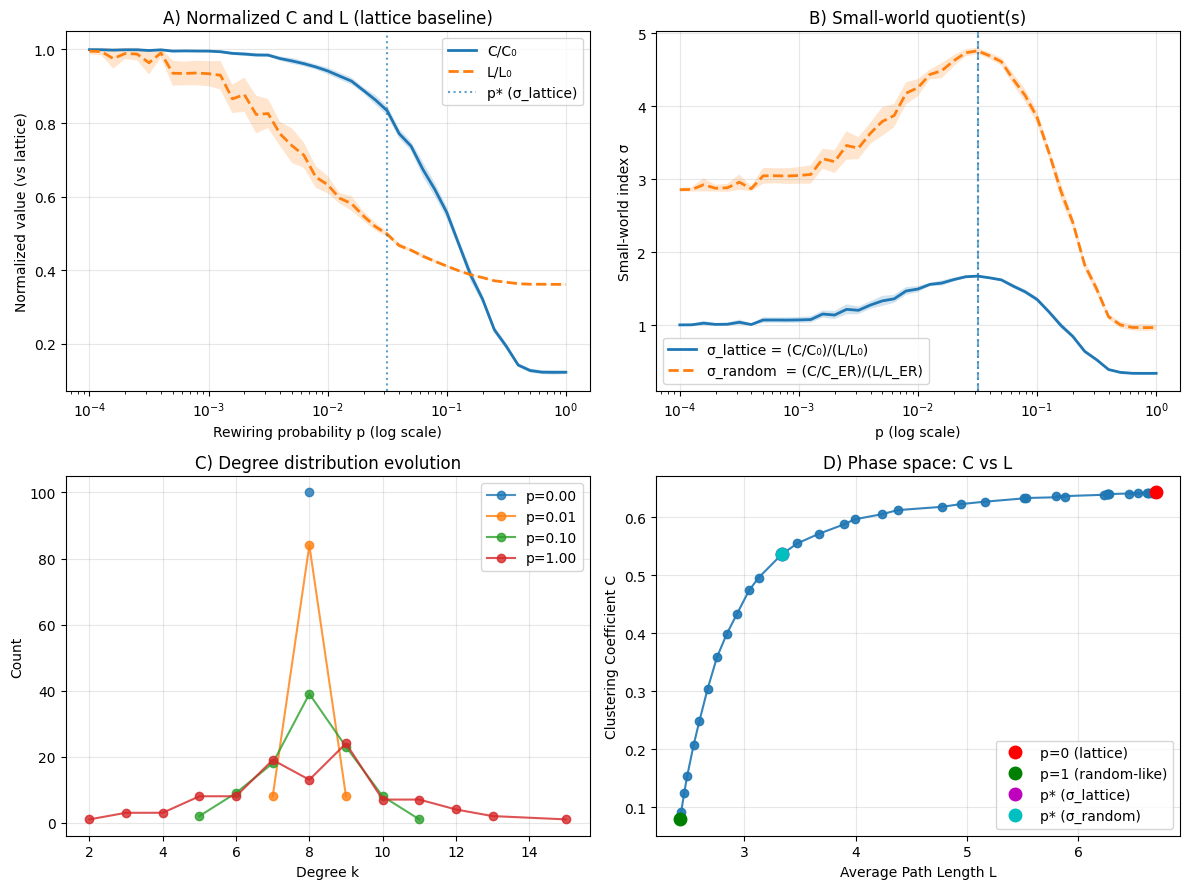

In [107]:
def analyze_small_world_quotient(
    size: int = 100,
    nei: int = 4,
    steps: int = 31,
    reps: int = 10,
    seed: int | None = 42,
    save_path: str | None = "imgs_output/small_world_analysis.png",
    show: bool = True,
):
    """
    Compute small-world quotients across rewiring probability p (Watts–Strogatz).

    Adds interpretability:
      - Reps per p -> mean ± 95% CI for all metrics
      - Two indices:
          σ_lattice = (C/C_lattice) / (L/L_lattice)
          σ_random  = (C/C_ER)      / (L/L_ER)
        where ER baseline has n=size and mean degree k≈2*nei (p_ER=k/(n-1)).
      - Degree distribution evolution at representative p's
      - C vs L phase plot

    Returns dict with ps, means/CIs, optimal p for both indices, and raw series.
    """
    print("\n" + "="*60)
    print("9. SMALL-WORLD QUOTIENT ANALYSIS — INTERPRETABLE")
    print("="*60)

    # Optional reproducibility
    if seed is not None:
        try:
            ig.set_random_number_generator(ig.RandomState(seed))
        except Exception:
            pass

    # Log-spaced rewiring probabilities
    ps = np.logspace(-4, 0, steps)

    # Baseline: regular lattice (p=0)
    lattice = ig.Graph.Watts_Strogatz(1, size, nei, p=0.0)
    C0 = lattice.transitivity_undirected()
    L0 = lattice.average_path_length()
    k = 2 * nei  # expected mean degree of WS
    p_er = k / (size - 1)

    print(f"\nBaseline lattice (p=0): C0={C0:.4f}, L0={L0:.3f}")
    print(f"ER baseline uses p_ER={p_er:.4f} (n={size}, k≈{k})")

    # Helpers
    def mean_ci(x):
        x = np.asarray(x, dtype=float)
        m = np.nanmean(x)
        s = np.nanstd(x, ddof=1)
        n_eff = np.sum(~np.isnan(x))
        ci = 1.96 * s / np.sqrt(n_eff) if n_eff > 0 else np.nan
        return m, ci

    # Storage
    C_mean, C_ci = [], []
    L_mean, L_ci = [], []
    Cl_mean, Cl_ci = [], []     # normalized by lattice C/C0
    Ll_mean, Ll_ci = [], []     # normalized by lattice L/L0
    Cr_mean, Cr_ci = [], []     # normalized by ER C/C_ER
    Lr_mean, Lr_ci = [], []     # normalized by ER L/L_ER
    sigma_l_mean, sigma_l_ci = [], []
    sigma_r_mean, sigma_r_ci = [], []

    # For phase plot
    C_vals_all, L_vals_all = [], []

    # Pre-compute ER baseline estimates (averaged over reps) — fixed across p
    C_er_list, L_er_list = [], []
    for _ in range(reps):
        g_er = ig.Graph.Erdos_Renyi(n=size, p=p_er, directed=False, loops=False)
        C_er_list.append(g_er.transitivity_undirected())
        L_er_list.append(g_er.average_path_length())
    C_er, C_er_ci = mean_ci(C_er_list)
    L_er, L_er_ci = mean_ci(L_er_list)

    for p in ps:
        C_list, L_list = [], []

        for _ in range(reps):
            ws = ig.Graph.Watts_Strogatz(dim=1, size=size, nei=nei, p=float(p))
            C_list.append(ws.transitivity_undirected())
            L_list.append(ws.average_path_length())

        # Means & CIs for raw C and L
        m, c = mean_ci(C_list); C_mean.append(m); C_ci.append(c)
        m, c = mean_ci(L_list); L_mean.append(m); L_ci.append(c)

        # Normalized by lattice
        Cl = np.array(C_list) / (C0 if C0 > 0 else np.nan)
        Ll = np.array(L_list) / (L0 if L0 > 0 else np.nan)
        m, c = mean_ci(Cl); Cl_mean.append(m); Cl_ci.append(c)
        m, c = mean_ci(Ll); Ll_mean.append(m); Ll_ci.append(c)

        # Normalized by ER
        Cr = np.array(C_list) / (C_er if C_er > 0 else np.nan)
        Lr = np.array(L_list) / (L_er if L_er > 0 else np.nan)
        m, c = mean_ci(Cr); Cr_mean.append(m); Cr_ci.append(c)
        m, c = mean_ci(Lr); Lr_mean.append(m); Lr_ci.append(c)

        # Small-world indices
        sigma_l = Cl / Ll  # vs lattice
        sigma_r = Cr / Lr  # vs ER
        m, c = mean_ci(sigma_l); sigma_l_mean.append(m); sigma_l_ci.append(c)
        m, c = mean_ci(sigma_r); sigma_r_mean.append(m); sigma_r_ci.append(c)

        # Save raw for phase plot (use means per p)
        C_vals_all.append(np.nanmean(C_list))
        L_vals_all.append(np.nanmean(L_list))

    # Arrays
    C_mean, C_ci = np.array(C_mean), np.array(C_ci)
    L_mean, L_ci = np.array(L_mean), np.array(L_ci)
    Cl_mean, Cl_ci = np.array(Cl_mean), np.array(Cl_ci)
    Ll_mean, Ll_ci = np.array(Ll_mean), np.array(Ll_ci)
    Cr_mean, Cr_ci = np.array(Cr_mean), np.array(Cr_ci)
    Lr_mean, Lr_ci = np.array(Lr_mean), np.array(Lr_ci)
    sigma_l_mean, sigma_l_ci = np.array(sigma_l_mean), np.array(sigma_l_ci)
    sigma_r_mean, sigma_r_ci = np.array(sigma_r_mean), np.array(sigma_r_ci)
    C_vals_all, L_vals_all = np.array(C_vals_all), np.array(L_vals_all)

    # Optimal p for each index
    idx_l = int(np.nanargmax(sigma_l_mean))
    idx_r = int(np.nanargmax(sigma_r_mean))
    p_opt_l, p_opt_r = ps[idx_l], ps[idx_r]

    print(f"\nOptimal p (vs lattice)  : p* ≈ {p_opt_l:.4f},  σ_lattice_max = {sigma_l_mean[idx_l]:.3f}")
    print(f"Optimal p (vs ER random): p* ≈ {p_opt_r:.4f},  σ_random_max  = {sigma_r_mean[idx_r]:.3f}")

    # -----------------------------
    # Visualization (2x2 dashboard)
    # -----------------------------
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # (A) Normalized metrics vs p (lattice baseline)
    ax = axes[0, 0]
    ax.semilogx(ps, Cl_mean, '-', label='C/C₀', linewidth=2)
    ax.fill_between(ps, Cl_mean - Cl_ci, Cl_mean + Cl_ci, alpha=0.2)
    ax.semilogx(ps, Ll_mean, '--', label='L/L₀', linewidth=2)
    ax.fill_between(ps, Ll_mean - Ll_ci, Ll_mean + Ll_ci, alpha=0.2)
    ax.axvline(p_opt_l, linestyle=':', label=f'p* (σ_lattice)', alpha=0.7)
    ax.set_xlabel('Rewiring probability p (log scale)')
    ax.set_ylabel('Normalized value (vs lattice)')
    ax.set_title('A) Normalized C and L (lattice baseline)')
    ax.grid(alpha=0.3)
    ax.legend(loc='best')

    # (B) Small-world indices vs p
    ax = axes[0, 1]
    ax.semilogx(ps, sigma_l_mean, '-', linewidth=2, label='σ_lattice = (C/C₀)/(L/L₀)')
    ax.fill_between(ps, sigma_l_mean - sigma_l_ci, sigma_l_mean + sigma_l_ci, alpha=0.2)
    ax.semilogx(ps, sigma_r_mean, '--', linewidth=2, label='σ_random  = (C/C_ER)/(L/L_ER)')
    ax.fill_between(ps, sigma_r_mean - sigma_r_ci, sigma_r_mean + sigma_r_ci, alpha=0.2)
    ax.axvline(p_opt_l, linestyle=':', alpha=0.6)
    ax.axvline(p_opt_r, linestyle='--', alpha=0.6)
    ax.set_xlabel('p (log scale)')
    ax.set_ylabel('Small-world index σ')
    ax.set_title('B) Small-world quotient(s)')
    ax.grid(alpha=0.3)
    ax.legend(loc='best')

    # (C) Degree distributions at representative p
    ax = axes[1, 0]
    reps_ps = [0.0, 0.01, 0.1, 1.0]
    for p in reps_ps:
        ws = ig.Graph.Watts_Strogatz(1, size, nei, p)
        degs = ws.degree()
        counts = Counter(degs)
        xs, ys = zip(*sorted(counts.items()))
        ax.plot(xs, ys, 'o-', label=f'p={p:.2f}', alpha=0.8)
    ax.set_xlabel('Degree k')
    ax.set_ylabel('Count')
    ax.set_title('C) Degree distribution evolution')
    ax.grid(alpha=0.3)
    ax.legend()

    # (D) Phase plot: C vs L (means over reps)
    ax = axes[1, 1]
    ax.plot(L_vals_all, C_vals_all, '-o', alpha=0.9)
    ax.plot(L0, C0, 'ro', markersize=9, label='p=0 (lattice)')
    # approximate p=1 point (last value)
    ax.plot(L_mean[-1], C_mean[-1], 'go', markersize=9, label='p=1 (random-like)')
    ax.plot(L_mean[idx_l], C_mean[idx_l], 'mo', markersize=9, label='p* (σ_lattice)')
    ax.plot(L_mean[idx_r], C_mean[idx_r], 'co', markersize=9, label='p* (σ_random)')
    ax.set_xlabel('Average Path Length L')
    ax.set_ylabel('Clustering Coefficient C')
    ax.set_title('D) Phase space: C vs L')
    ax.grid(alpha=0.3)
    ax.legend(loc='best')

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\nPlot saved as '{save_path}'")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "ps": ps,
        "C_mean": C_mean, "C_ci": C_ci,
        "L_mean": L_mean, "L_ci": L_ci,
        "Cl_mean": Cl_mean, "Cl_ci": Cl_ci,
        "Ll_mean": Ll_mean, "Ll_ci": Ll_ci,
        "Cr_mean": Cr_mean, "Cr_ci": Cr_ci,
        "Lr_mean": Lr_mean, "Lr_ci": Lr_ci,
        "sigma_l_mean": sigma_l_mean, "sigma_l_ci": sigma_l_ci,
        "sigma_r_mean": sigma_r_mean, "sigma_r_ci": sigma_r_ci,
        "p_opt_lattice": p_opt_l,
        "p_opt_random": p_opt_r,
        "C0": C0, "L0": L0,
        "C_ER": C_er, "L_ER": L_er,
    }

res_sw = analyze_small_world_quotient(size=100, nei=4, steps=41, reps=20, seed=123)


This is a **four‑panel** summary for the Watts–Strogatz model (WS) with $n=30$, initial ring degree $k=8$, rewiring probability $p \in [10^{-4},1]$ (log‑spaced).

#### **Top‑Left: Normalized $C/C_0$ and $L/L_0$ vs $p$**

* $C_0$ and $L_0$ are the clustering and average path length at $p=0$ (pure ring).
* **Blue**: $C/C_0$ stays near $1$ for small $p$, then declines.
* **Red**: $L/L_0$ drops **very fast** even for tiny $p$ due to a few long‑range **shortcuts**.
* **Green vertical dashed** line marks a canonical **small‑world window** where $L$ is already small while $C$ remains high.

#### **Top‑Right: Small‑World Quotient $Q(p)$**

* We define a simple quotient $Q(p)$ proportional to $C/L$ (often normalized by ER references). Here we inspect the raw ratio as a proxy:
  $$Q(p) = \frac{C(p)}{L(p)}.$$
* **Red dashed vertical** line indicates the empirical maximizer.
* **Observation**: $Q(p)$ peaks around $p_{\text{opt}}\approx 3\cdot10^{-2}$.

#### **Bottom‑Left: Degree Distribution Evolution**

* Shows histograms for degrees at representative $p$ values:

  * $p=0$: **delta‑peak** at $k=8$ (regular ring).
  * $p=0.01,0.10$: distribution widens as random rewiring introduces heterogeneity.
  * $p=1$: close to **Poisson‑like** ER distribution (for fixed $\bar{k}$).

#### **Bottom‑Right: Phase Space ($C$ vs $L$)**

* Blue trajectory as $p$ increases: starts at **lattice** (high $C$, high $L$), moves left/down toward **random** (low $C$, low $L$).
* Markers:

  * **Red**: $p=0$ (lattice)
  * **Magenta**: $p\approx p_{\text{opt}}$ (optimal small‑world)
  * **Green**: $p=1$ (random)
* **Takeaway**: There exists a region where $L$ is **almost as small** as random but $C$ is **still high** → the hallmark of a **small‑world network**.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# A) DATA FRAMES (R parity → pandas)
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (A): In R, data frames sometimes coerce strings to factors; in Python we
use pandas with explicit dtypes. We'll create a tiny table of vertices with
id, name, gender, age; then do simple filters. This mirrors the slide vibe
without the stringsAsFactors surprise.
"""

# Create a small vertex table (use string dtype explicitly)
V = pd.DataFrame({
    'id':   [0, 1, 2, 3, 4, 5],
    'name': pd.Series(['Ana','Bob','Cy','Dia','Eli','Flo'], dtype='string'),
    'gender': pd.Series(['f','m','m','f','f','f'], dtype='string'),
    'age':  [22, 35, 29, 41, 31, 27]
})

print("Vertices table (V) — head:\n", V.head(), "\n")
print("People > 30:\n", V[V.age > 30][['id','name','age']])

# Tip: enforce categories if you want R‑like factors
V['gender_cat'] = V['gender'].astype('category')

Vertices table (V) — head:
    id name gender  age
0   0  Ana      f   22
1   1  Bob      m   35
2   2   Cy      m   29
3   3  Dia      f   41
4   4  Eli      f   31 

People > 30:
    id name  age
1   1  Bob   35
3   3  Dia   41
4   4  Eli   31


Graph: IGRAPH UNW- 6 12 -- 
+ attr: age (v), gender (v), name (v), type (e), weight (e)
Vertex attributes: ['name', 'gender', 'age']
Edge attributes: ['type', 'weight']

First 10 edges with attributes:
    source  target   type  weight
0       0       1  email       3
1       0       2  email       1
2       1       2  email       2
3       1       3   chat       5
4       2       3   chat       1
5       2       4   chat       7
6       3       4  email       2
7       3       5  email       4
8       4       5   chat       1
9       5       0  email       2

Adjacency shape: (6, 6)
[[0 1 1 0 0 1]
 [1 0 1 1 0 1]
 [1 1 0 1 1 1]
 [0 1 1 0 1 1]
 [0 0 1 1 0 1]
 [1 1 1 1 1 0]]

First 10 edge tuples: [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (3, 5), (4, 5), (0, 5)]


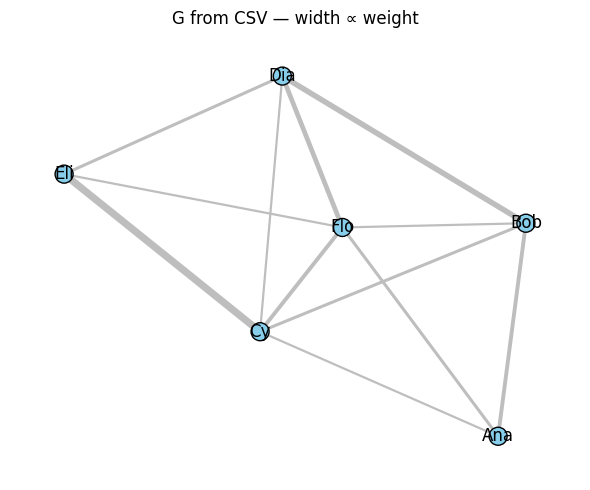

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# B) READ NETWORKS FROM FILES (edge list + node table)
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (B): We'll show a standard workflow: load nodes.csv + edges.csv with
attributes, build an igraph, check attributes, preview adjacency and edgelist,
then plot with edge width ∝ weight. Density uses $\rho=\tfrac{2|E|}{|V|(|V|-1)}$.
"""

import igraph as ig
import matplotlib.pyplot as plt
ig.config["plotting.backend"] = "matplotlib"

# Cell B0 — OPTIONAL: create example CSVs in the working directory
# (Run once if you don't already have your own files.)
V.to_csv('nodes.csv', index=False)
E_demo = pd.DataFrame({
    'source': [0,0,1,1,2,  2,3,3,4,5,  5,5],
    'target': [1,2,2,3,3,  4,4,5,5,0,  1,2],
    'type':   ['email','email','email','chat','chat', 'chat','email','email','chat','email','chat','email'],
    'weight': [3,1,2,5,1,   7,2,4,1,2,   1,3]
})
E_demo.to_csv('edges.csv', index=False)

# Cell B1 — load CSVs and build the graph
nodes_df = pd.read_csv('nodes.csv')
edges_df = pd.read_csv('edges.csv')

# Ensure integer ids for igraph construction
nodes_df['id'] = nodes_df['id'].astype(int)
edges_df['source'] = edges_df['source'].astype(int)
edges_df['target'] = edges_df['target'].astype(int)

# Build graph from tuples; attach attributes
G = ig.Graph()
G.add_vertices(nodes_df.shape[0])
G.vs['name'] = nodes_df['name'].astype(str).tolist()
G.vs['gender'] = nodes_df['gender'].astype(str).tolist()
G.vs['age'] = nodes_df['age'].tolist()

G.add_edges(list(zip(edges_df['source'], edges_df['target'])))
G.es['type'] = edges_df['type'].astype(str).tolist()
G.es['weight'] = edges_df['weight'].tolist()

# Basic sanity prints
print("Graph:", G.summary())
print("Vertex attributes:", G.vs.attributes())
print("Edge attributes:", G.es.attributes())

# Preview first 10 edges in a card‑style table
print("\nFirst 10 edges with attributes:\n", edges_df.head(10))

# Adjacency (for small graphs)
A = np.array(G.get_adjacency().data)
print("\nAdjacency shape:", A.shape)
print(A)

# Edgelist
print("\nFirst 10 edge tuples:", G.get_edgelist()[:10])

# Plot with edge width ∝ weight
plt.figure(figsize=(6,5))
layout = G.layout('fr')
edge_w = [1 + 0.6*w for w in G.es['weight']]
ig.plot(
    G, target=plt.gca(), layout=layout,
    vertex_size=18, vertex_color='skyblue', vertex_label=G.vs['name'],
    edge_width=edge_w, edge_color='gray', margin=30
)
plt.title('G from CSV — width ∝ weight')
plt.tight_layout(); plt.show()

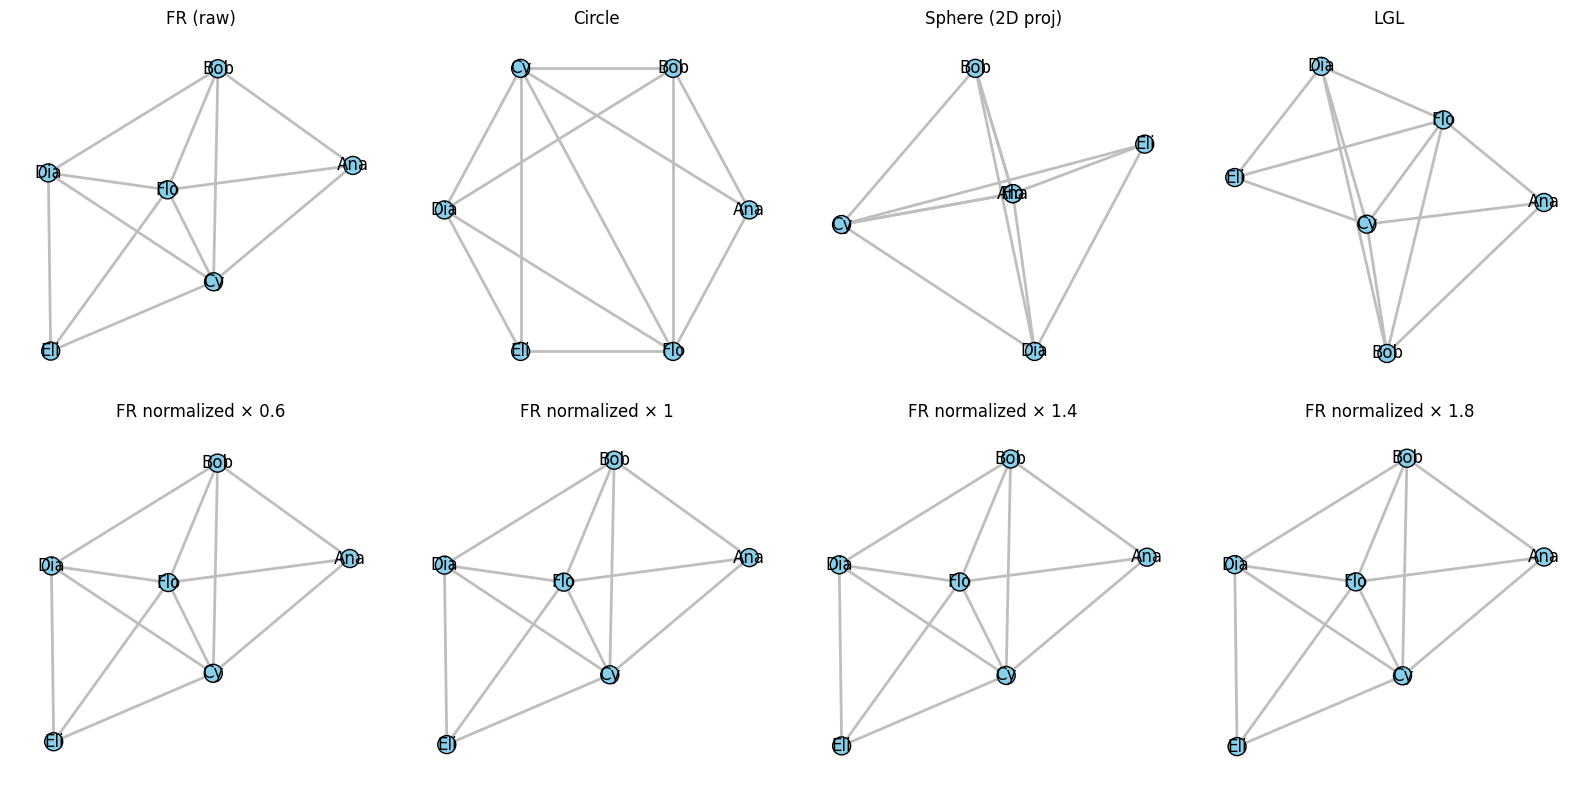

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# B.1) LAYOUT GALLERY & RESCALING — robust to 3D layouts (e.g., 'sphere')
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import igraph as ig

assert 'G' in globals(), "This cell expects your CSV graph `G`."

def layout_2d(lay) -> ig.Layout:
    """Ensure a layout is 2D for Matplotlib plotting."""
    arr = np.asarray(lay, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f"Unexpected layout shape: {arr.shape}")
    arr2 = arr[:, :2]  # drop z if present
    return ig.Layout(arr2.tolist())

# Compute a few layouts (some may be 3D -> coerce)
L_fr     = layout_2d(G.layout('fr'))
L_circle = layout_2d(G.layout('circle'))
L_sphere = layout_2d(G.layout('sphere'))   # was 3D → now sliced to 2D
L_lgl    = layout_2d(G.layout('lgl'))

# ---- Rescale/normalize FR coordinates to [-1,1] ----
L = np.array(L_fr, dtype=float)  # shape (n,2)
xmin, ymin = L.min(axis=0)
xmax, ymax = L.max(axis=0)
denom = np.array([xmax - xmin, ymax - ymin]) + 1e-12
L01 = (L - np.array([xmin, ymin])) / denom
Lpm = (L01 * 2.0) - 1.0  # [-1, 1]

# Plot: four layouts side-by-side, then reuse normalized FR at multiple scales
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
layouts = [L_fr, L_circle, L_sphere, L_lgl]
titles  = ["FR (raw)", "Circle", "Sphere (2D proj)", "LGL"]

for ax, lay, tt in zip(axes[:4], layouts, titles):
    ig.plot(
        G, target=ax, layout=lay,
        vertex_size=18, vertex_color='skyblue', vertex_label=G.vs['name'],
        edge_color='gray', margin=30, bbox=(400, 400)
    )
    ax.set_title(tt)

# Reuse normalized FR at different scales
for ax, scale in zip(axes[4:], [0.6, 1.0, 1.4, 1.8]):
    ig.plot(
        G, target=ax, layout=(Lpm * scale),
        vertex_size=18, vertex_color='skyblue', vertex_label=G.vs['name'],
        edge_color='gray', margin=30, bbox=(400, 400)
    )
    ax.set_title(f"FR normalized × {scale:g}")

plt.tight_layout()
plt.show()


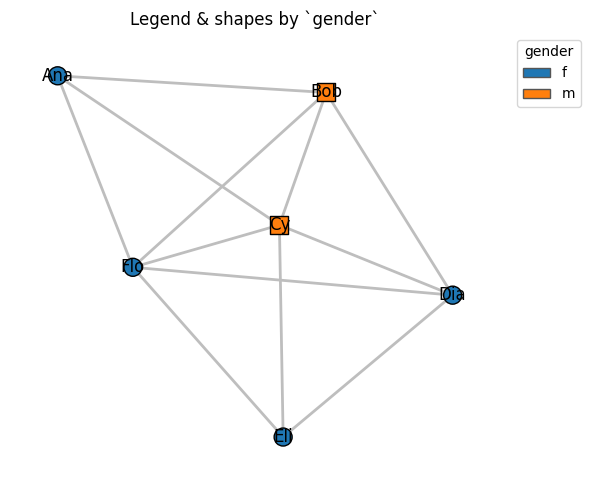

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# B.2) LEGENDS, SHAPES & LABEL STYLING (uses node attr; defaults to 'gender')
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

assert 'G' in globals() and 'nodes_df' in globals(), \
    "This cell expects `G` and `nodes_df` (with a categorical column like 'gender')."

# Choose a categorical vertex attribute that exists; fallback to 'gender'
cat_attr = 'gender' if 'gender' in G.vs.attributes() else None
if cat_attr is None:
    # create a demo categorical attr if none exists
    G.vs['gender'] = ['f' if i % 2 == 0 else 'm' for i in range(G.vcount())]
    cat_attr = 'gender'

# Map categories → colors/shapes
cats = sorted({c for c in G.vs[cat_attr]})
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
shapes  = ['circle', 'square', 'triangle-up', 'triangle-down', 'diamond']

color_map = {c: palette[i % len(palette)] for i, c in enumerate(cats)}
shape_map = {c: shapes[i % len(shapes)] for i, c in enumerate(cats)}

vcolor = [color_map[c] for c in G.vs[cat_attr]]
vshape = [shape_map[c] for c in G.vs[cat_attr]]

fig, ax = plt.subplots(figsize=(6, 5))
ig.plot(
    G, target=ax, layout=G.layout('fr'),
    vertex_color=vcolor, vertex_shape=vshape,
    vertex_size=18, vertex_label=G.vs['name'], edge_color='gray',
    margin=30
)
ax.set_title(f"Legend & shapes by `{cat_attr}`")

# Build a simple legend
legend_handles = [Patch(facecolor=color_map[c], edgecolor='#555555', label=str(c)) for c in cats]
ax.legend(handles=legend_handles, title=cat_attr, loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()

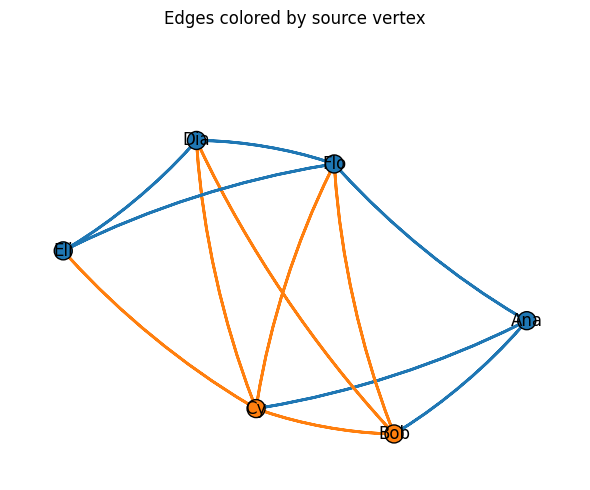

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# B.3) EDGE COLOR FROM SOURCE VERTEX COLOR
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

assert 'G' in globals(), "This cell expects your CSV graph `G`."

# Use existing vertex colors if set; otherwise, derive from a categorical attr
if 'color' in G.vs.attributes():
    vcolor = G.vs['color']
else:
    base_attr = 'gender' if 'gender' in G.vs.attributes() else None
    if base_attr is None:
        G.vs['gender'] = ['f' if i % 2 == 0 else 'm' for i in range(G.vcount())]
        base_attr = 'gender'
    cats = sorted({c for c in G.vs[base_attr]})
    palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
    cmap = {c: palette[i % len(palette)] for i, c in enumerate(cats)}
    vcolor = [cmap[c] for c in G.vs[base_attr]]

# Color each edge by its source vertex color
edge_starts = [e.tuple[0] for e in G.es]
edge_color  = [vcolor[s] for s in edge_starts]

fig, ax = plt.subplots(figsize=(6, 5))
lay = G.layout('fr')
ig.plot(
    G, target=ax, layout=lay,
    vertex_size=18, vertex_color=vcolor, vertex_label=G.vs['name'],
    edge_color=edge_color, edge_curved=0.1, margin=30
)
ax.set_title("Edges colored by source vertex")
plt.tight_layout()
plt.show()

Pre‑aggregation reduced edges from 12 to 12
Before simplify — multigraph edges: 12
After simplify  — simple edges: 12


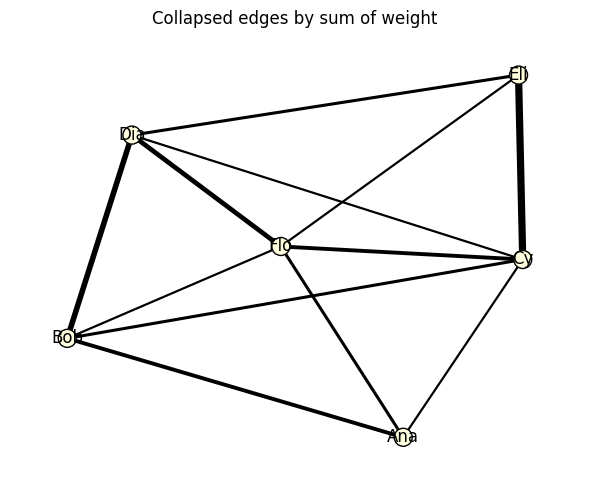

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# C) WEIGHTED NETWORKS & COLLAPSING MULTIPLE EDGES
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (C): Two routes to merge multiple interactions between the same pair:
(1) pre‑aggregate the edgelist with pandas (groupby sum), then build a simple
weighted graph; (2) build a multigraph and call simplify with
combine_edges={'weight':'sum'}. We'll compare counts before/after.
"""

# Cell C1 — Pre‑aggregate in pandas BEFORE graph construction
edges_agg = (edges_df
             .groupby(['source','target','type'], as_index=False)
             .agg(weight=('weight','sum')))
print("Pre‑aggregation reduced edges from", len(edges_df), "to", len(edges_agg))

G_pre = ig.Graph()
G_pre.add_vertices(nodes_df.shape[0])
G_pre.vs['name'] = nodes_df['name'].astype(str).tolist()
G_pre.add_edges(list(zip(edges_agg['source'], edges_agg['target'])))
G_pre.es['weight'] = edges_agg['weight'].tolist()

# Cell C2 — Post‑hoc simplification on a multigraph
# Build a multigraph first (allowing parallel edges)
G_multi = ig.Graph()
G_multi.add_vertices(nodes_df.shape[0])
G_multi.vs['name'] = nodes_df['name'].astype(str).tolist()
G_multi.add_edges(list(zip(edges_df['source'], edges_df['target'])))
G_multi.es['weight'] = edges_df['weight'].tolist()

print("Before simplify — multigraph edges:", G_multi.ecount())
G_simpl = G_multi.simplify(loops=True, combine_edges=dict(weight="sum"))
print("After simplify  — simple edges:", G_simpl.ecount())

# Quick plot to show thicker combined edge(s)
plt.figure(figsize=(6,5))
ig.plot(
    G_simpl, target=plt.gca(), layout=G_simpl.layout('fr'),
    vertex_size=18, vertex_color='lightyellow', vertex_label=G_simpl.vs['name'],
    edge_width=[1 + 0.6*w for w in G_simpl.es['weight']], edge_color='black', margin=30
)
plt.title('Collapsed edges by sum of weight')
plt.tight_layout(); plt.show()


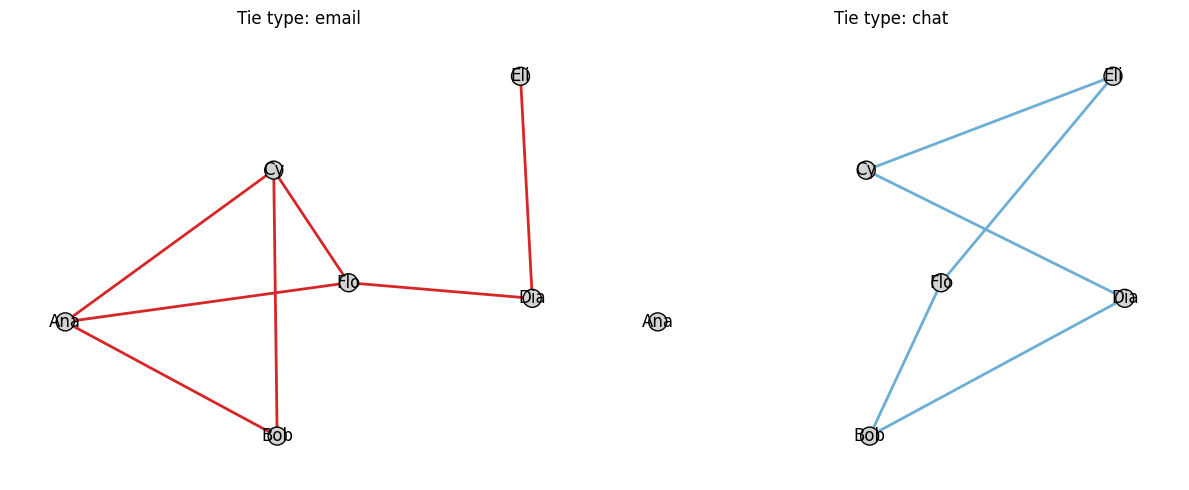

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# C.1) EDGE-TYPE SUBGRAPHS (same layout for side-by-side comparison)
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd

assert 'G' in globals() and 'edges_df' in globals(), "This cell expects `G` and `edges_df`."

# Identify the two most common edge types (fallbacks to all if <2 types)
type_counts = edges_df['type'].value_counts()
edge_types = list(type_counts.index[:2]) if not type_counts.empty else []
if len(edge_types) < 2:
    edge_types = sorted(set(edges_df['type']))[:2]

# Build subgraphs by edge type via edge ID filtering
def subgraph_by_type(edge_type: str) -> ig.Graph:
    eids = [e.index for e in G.es if e['type'] == edge_type]
    g_sub = G.subgraph_edges(eids, delete_vertices=False)
    return g_sub

gA = subgraph_by_type(edge_types[0]) if edge_types else G.copy()
gB = subgraph_by_type(edge_types[1]) if len(edge_types) > 1 else G.copy()

# Use the SAME layout coordinates from the full graph for both
L_full = G.layout('fr')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, g_sub, label, color in zip(
    axes, [gA, gB], edge_types,
    ['#d62728', '#6baed6']
):
    ig.plot(
        g_sub, target=ax, layout=L_full,
        vertex_size=18, vertex_color='lightgray', vertex_label=G.vs['name'],
        edge_color=color, margin=30
    )
    ax.set_title(f"Tie type: {label}")

plt.tight_layout()
plt.show()


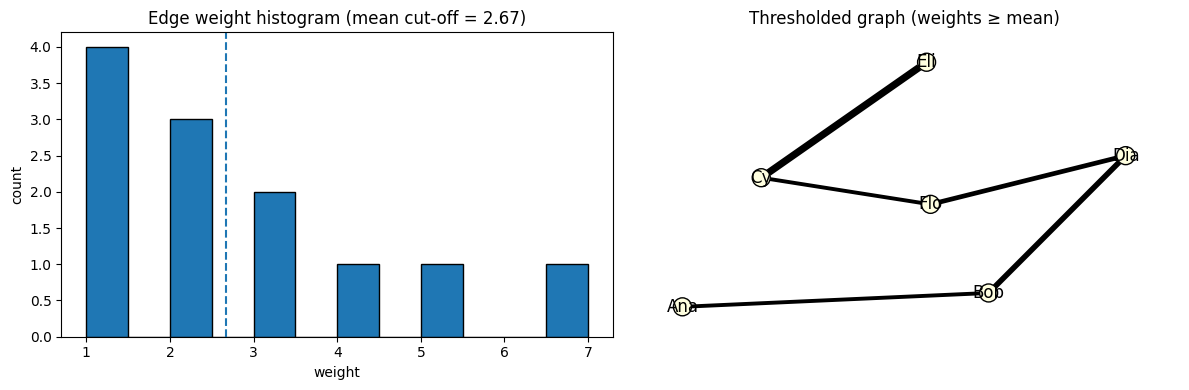

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# C.2) WEIGHT THRESHOLDING (drop weak ties below mean weight)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

assert 'G' in globals(), "This cell expects your CSV graph `G`."

weights = np.array(G.es['weight'], dtype=float)
cutoff = float(np.nanmean(weights))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(weights, bins=12, edgecolor='black')
ax[0].axvline(cutoff, linestyle='--')
ax[0].set_title(f"Edge weight histogram (mean cut-off = {cutoff:.3g})")
ax[0].set_xlabel("weight"); ax[0].set_ylabel("count")

# Delete edges < cutoff (non-destructive)
G_thr = G.copy()
to_drop = [e.index for e in G_thr.es if float(e['weight']) < cutoff]
G_thr.delete_edges(to_drop)

ig.plot(
    G_thr, target=ax[1], layout=G.layout('fr'),
    vertex_size=18, vertex_color='lightyellow', vertex_label=G.vs['name'],
    edge_color='black', edge_width=[1 + 0.6*w for w in G_thr.es['weight']],
    margin=30
)
ax[1].set_title("Thresholded graph (weights ≥ mean)")
plt.tight_layout()
plt.show()


Karate: N=34, L=78, k_bar=4.59, rho=0.1390, C=0.2557, APL=2.408, D=5


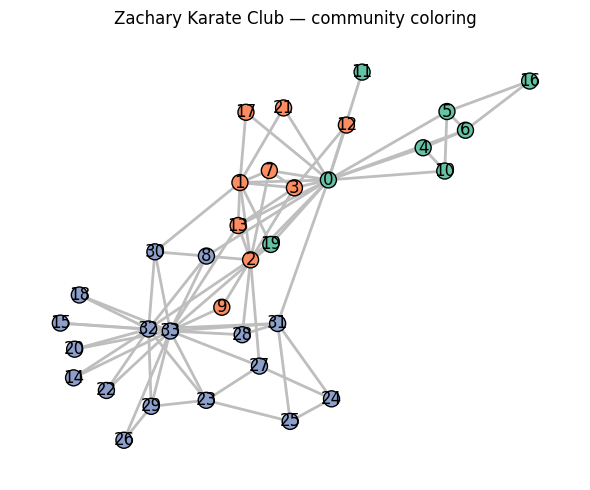

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# D) KARATE CLUB — QUICK CHARACTERIZATION
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (D): The Zachary Karate Club network is a classic social graph. We'll
compute global stats $N, L, \bar{k}, \rho, C, L_{APL}, D$, find communities,
and plot with colors. Expect two main communities (the historical split).
"""

# Cell D1 — Load and stats
K = ig.Graph.Famous('Zachary')  # undirected, simple
N, L = K.vcount(), K.ecount()
mean_k = np.mean(K.degree())
rho = 2*L/(N*(N-1))
C = K.transitivity_undirected()
L_apl = K.average_path_length()
D_diam = K.diameter()

print(f"Karate: N={N}, L={L}, k_bar={mean_k:.2f}, rho={rho:.4f}, C={C:.4f}, APL={L_apl:.3f}, D={D_diam}")

# Cell D2 — Community detection (on undirected, weights ignored here)
communities = K.community_fastgreedy().as_clustering()
colors = [communities.membership[v.index] for v in K.vs]
# map to a palette
palette = ['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f']
vertex_color = [palette[c % len(palette)] for c in colors]

plt.figure(figsize=(6,5))
ig.plot(
    K, target=plt.gca(), layout=K.layout('fr'),
    vertex_size=16, vertex_color=vertex_color, vertex_label=[str(i) for i in range(N)],
    edge_color='gray', margin=30
)
plt.title('Zachary Karate Club — community coloring')
plt.tight_layout(); plt.show()



C:\Users\emanu\AppData\Local\Temp\ipykernel_12732\1446390040.py:16: DeprecationWarning: Graph.Incidence() is deprecated; use Graph.Biadjacency() instead
  G2 = ig.Graph.Incidence(B.tolist(), directed=False)


Bipartite graph: IGRAPH U--T 20 26 -- 
+ attr: type (v)
V['type'] counts: {True: 12, False: 8}


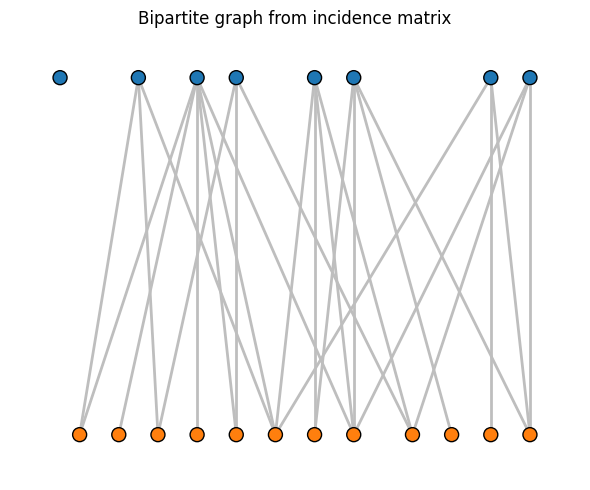

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# E) FROM MATRICES: ADJACENCY & INCIDENCE (BIPARTITE)
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (E): In a bipartite network we have two disjoint node sets. We'll build
an incidence matrix B (size S×U) with 0/1 entries and use
Graph.Incidence(B). igraph sets V['type'] to 0/1 to mark the modes.
"""

# Cell E1 — build a small incidence matrix
np.random.seed(0)
S, U = 8, 12  # sources × users (two modes)
B = (np.random.rand(S, U) < 0.25).astype(int)

# Create bipartite graph (undirected)
G2 = ig.Graph.Incidence(B.tolist(), directed=False)
print("Bipartite graph:", G2.summary())
print("V['type'] counts:", pd.Series(G2.vs['type']).value_counts().to_dict())

# Plot with two colors for the modes
mode_colors = ['#1f77b4', '#ff7f0e']
vc = [mode_colors[int(t)] for t in G2.vs['type']]
plt.figure(figsize=(6,5))
ig.plot(
    G2, target=plt.gca(), layout=G2.layout('bipartite'),
    vertex_size=14, vertex_color=vc, vertex_label=None,
    edge_color='gray', margin=30
)
plt.title('Bipartite graph from incidence matrix')
plt.tight_layout(); plt.show()

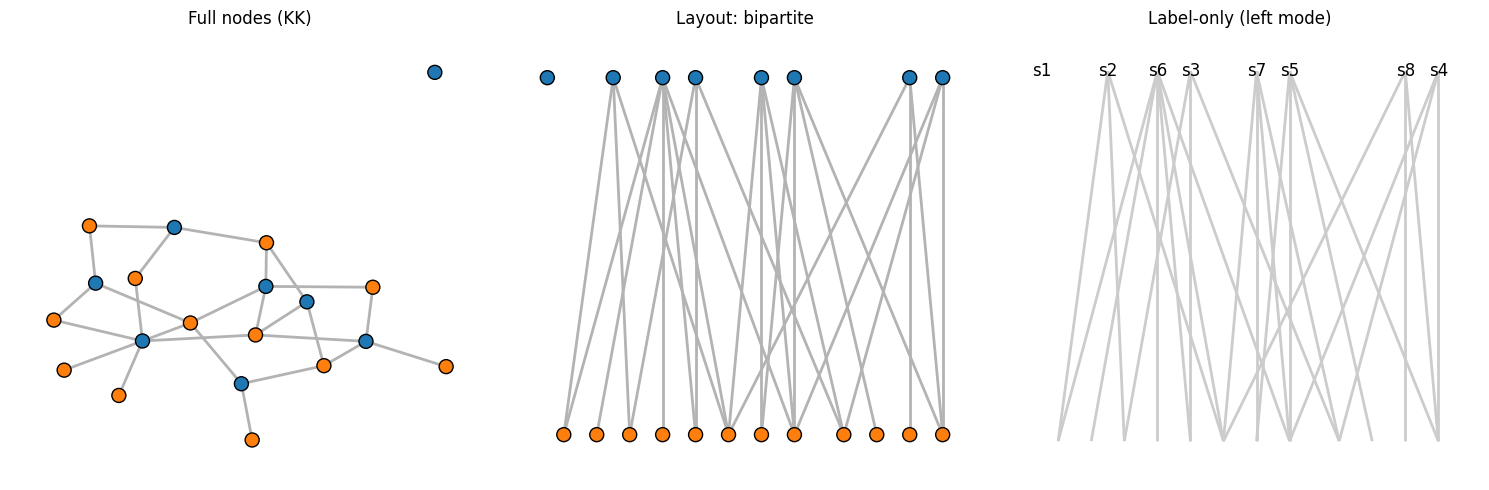

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# E.1) BIPARTITE PRESET VIEWS (fixed label colors & invisible node trick)
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import igraph as ig

assert 'G2' in globals() and 'S' in globals() and 'U' in globals(), \
    "This cell expects your bipartite `G2` built from incidence `B` with sizes S×U."

mode_colors = ['#1f77b4', '#ff7f0e']
vc = [mode_colors[int(t)] for t in G2.vs['type']]
lay_bi = G2.layout('bipartite')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Full nodes (any layout)
ig.plot(
    G2, target=axes[0], layout=G2.layout('kk'),
    vertex_size=14, vertex_color=vc, vertex_label=None,
    edge_color='#B3B3B3', margin=30
)
axes[0].set_title('Full nodes (KK)')

# (b) Bipartite layout (rows by mode)
ig.plot(
    G2, target=axes[1], layout=lay_bi,
    vertex_size=14, vertex_color=vc, vertex_label=None,
    edge_color='#B3B3B3', margin=30
)
axes[1].set_title('Layout: bipartite')

# (c) Label-only view of one mode (left mode labels only)
labels = ["" for _ in range(G2.vcount())]
for i, t in enumerate(G2.vs['type']):
    if t == 0:  # left mode
        labels[i] = f"s{i+1}"  # or G2.vs['name'][i] if available

# make vertices invisible but keep edges
invisible_size = [0.01] * G2.vcount()
ig.plot(
    G2, target=axes[2], layout=lay_bi,
    vertex_shape='circle', vertex_size=invisible_size,
    vertex_frame_width=0, vertex_color=['#FFFFFF'] * G2.vcount(),
    vertex_label=labels, vertex_label_color='black', vertex_label_size=12,
    edge_color='#CCCCCC', margin=30
)
axes[2].set_title('Label-only (left mode)')

plt.tight_layout()
plt.show()

Left projection: IGRAPH U-WT 8 17 -- 
+ attr: type (v), weight (e)
Right projection: IGRAPH U-WT 12 34 -- 
+ attr: type (v), weight (e)

Sample weight checks (left projection):
(1,2) manual=1  api=1
(1,5) manual=2  api=2
(1,6) manual=1  api=1
(1,7) manual=1  api=1
(2,3) manual=1  api=1
(2,5) manual=1  api=1
(2,6) manual=1  api=1
(3,4) manual=2  api=2


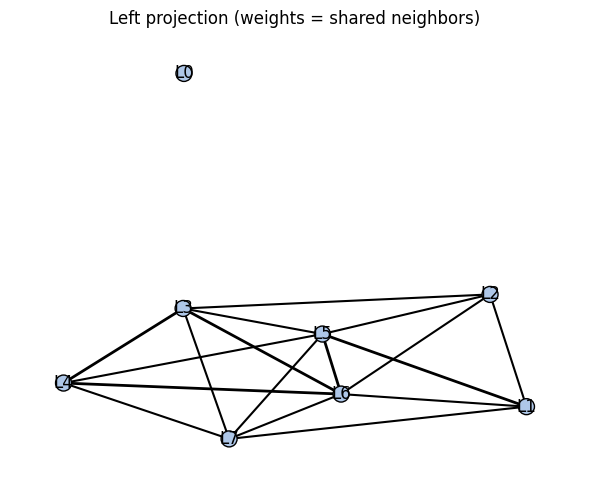

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# F) BIPARTITE PROJECTIONS (API + MANUAL CHECK)
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (F): The left projection connects two left‑mode nodes if they share at
least one neighbor on the right; weight $w_{ij}$ counts shared neighbors.
We'll compute projections via API and compare to manual matrices: BB^T and B^T B.
"""

# Cell F1 — API projections
left_proj, right_proj = G2.bipartite_projection(multiplicity=True)
print("Left projection:", left_proj.summary())
print("Right projection:", right_proj.summary())

# Cell F2 — Manual matrices and comparison (weights)
B_mat = B  # S×U
W_left = B_mat @ B_mat.T     # S×S
W_right = B_mat.T @ B_mat    # U×U

# Extract weights from igraph left projection into a dict {(i,j): w}
api_w = {(e.tuple[0], e.tuple[1]): e['weight'] for e in left_proj.es}

# Compare a few pairs (upper triangle)
print("\nSample weight checks (left projection):")
checks = 0
for i in range(S):
    for j in range(i+1, S):
        if W_left[i, j] > 0:
            w_api = api_w.get((i, j)) or api_w.get((j, i))
            print(f"({i},{j}) manual={W_left[i,j]}  api={w_api}")
            checks += 1
            if checks >= 8:
                break
    if checks >= 8:
        break

# Plot left projection with width ∝ weight
plt.figure(figsize=(6,5))
edge_w = [1 + 0.5*w for w in left_proj.es['weight']]
ig.plot(
    left_proj, target=plt.gca(), layout=left_proj.layout('fr'),
    vertex_size=16, vertex_color='#aec7e8', vertex_label=[f"L{i}" for i in range(S)],
    edge_width=edge_w, edge_color='black', margin=30
)
plt.title('Left projection (weights = shared neighbors)')
plt.tight_layout(); plt.show()

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# G) CONVERSIONS & EXPORTS (as_* helpers)
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (G): Round‑tripping is essential. We'll preview get_edgelist(),
get_adjacency(), convert to a DataFrame‑like view, and export to GraphML.
"""

# Cell G1 — get_edgelist and get_adjacency on the CSV graph G
print("First 8 edgelist tuples:", G.get_edgelist()[:8])
A_G = np.array(G.get_adjacency().data)
print("Adjacency shape:", A_G.shape)

# Cell G2 — vertices/edges as DataFrame‑style dicts
edges_view = pd.DataFrame({
    'source': [e.tuple[0] for e in G.es],
    'target': [e.tuple[1] for e in G.es],
    'weight': G.es['weight']
})
verts_view = pd.DataFrame({
    'id': list(range(G.vcount())),
    'name': G.vs['name'],
    'age': G.vs['age'],
    'gender': G.vs['gender']
})
print("\nEdges view (head):\n", edges_view.head())
print("\nVertices view (head):\n", verts_view.head())

# Cell G3 — export to GraphML (portable)
ig.write(G, 'graph_from_csv.graphml')
print("Exported: graph_from_csv.graphml")

First 8 edgelist tuples: [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (3, 5)]
Adjacency shape: (6, 6)

Edges view (head):
    source  target  weight
0       0       1       3
1       0       2       1
2       1       2       2
3       1       3       5
4       2       3       1

Vertices view (head):
    id name  age gender
0   0  Ana   22      f
1   1  Bob   35      m
2   2   Cy   29      m
3   3  Dia   41      f
4   4  Eli   31      f
Exported: graph_from_csv.graphml


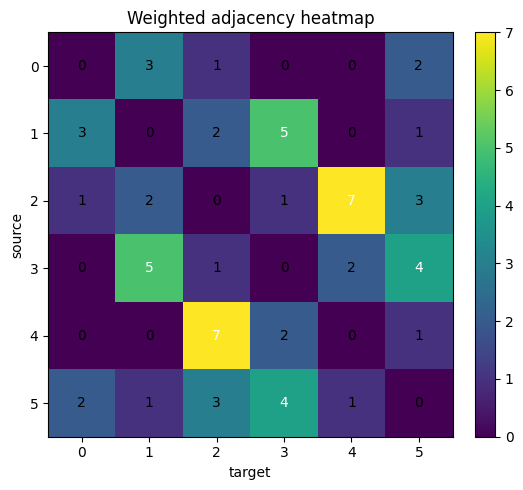

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# G.1) WEIGHTED ADJACENCY HEATMAP (imshow)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

assert 'G' in globals(), "This cell expects your CSV graph `G`."

# Get weighted adjacency; default=0 fills missing entries
A_w = np.array(G.get_adjacency(attribute='weight', default=0).data, dtype=float)

plt.figure(figsize=(6, 5))
im = plt.imshow(A_w, interpolation='nearest')
# add values inside
for i in range(A_w.shape[0]):
    for j in range(A_w.shape[1]):
        plt.text(j, i, int(A_w[i, j]), ha='center', va='center', color='white' if A_w[i, j] > A_w.max()/2 else 'black')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Weighted adjacency heatmap")
plt.xlabel("target"); plt.ylabel("source")
plt.tight_layout()
plt.show()


Simple weighted graph: N=6, L=12, k_bar=4.00, rho=0.8000, C=0.7895, APL=1.2, D=2

Top‑5 by weighted degree (strength):
    id name  strength
2   2   Cy      14.0
3   3  Dia      12.0
1   1  Bob      11.0
5   5  Flo      11.0
4   4  Eli      10.0


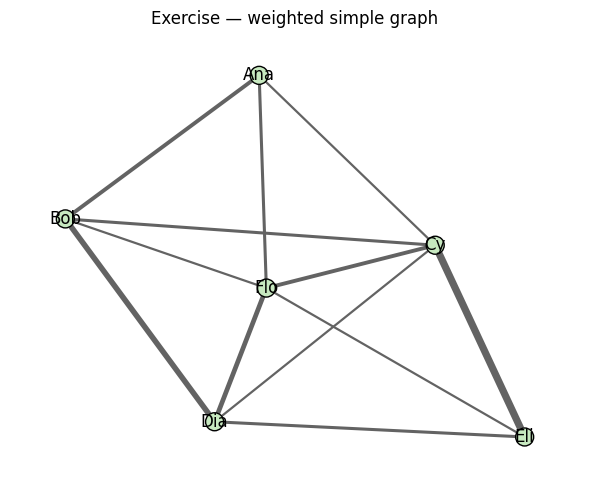

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# H) MINI‑EXERCISE (auto‑check style prompts)
# ─────────────────────────────────────────────────────────────────────────────
"""
Story (H): Given an edgelist with types+weights, build a simple weighted graph;
remove loops; collapse multiples; report $N,L,\rho,\bar{k},C,L_{APL},D$;
list top‑5 nodes by weighted degree. If the graph is bipartite, also project to
left mode and print top‑5 edges by weight. The code below is structured so you
can point it to your CSVs and run.
"""

# Cell H1 — parameterize filenames (edit these or reuse nodes.csv/edges.csv)
NODES_CSV = 'nodes.csv'   # columns: id,name,gender,age
EDGES_CSV = 'edges.csv'   # columns: source,target,type,weight
IS_BIPARTITE = False      # set True if edges connect across two modes only

# Cell H2 — load and build weighted simple graph
nodes_df = pd.read_csv(NODES_CSV)
edges_df = pd.read_csv(EDGES_CSV)

# sanitize types
for col in ('source','target'):
    edges_df[col] = edges_df[col].astype(int)

# Remove self‑loops in the edgelist itself
edges_df = edges_df[edges_df['source'] != edges_df['target']].copy()

# Collapse multiples by sum of weight
edges_w = (edges_df.groupby(['source','target'], as_index=False)
                    .agg(weight=('weight','sum')))

H_G = ig.Graph()
H_G.add_vertices(nodes_df.shape[0])
H_G.vs['name'] = nodes_df['name'].astype(str).tolist()
H_G.add_edges(list(zip(edges_w['source'], edges_w['target'])))
H_G.es['weight'] = edges_w['weight'].tolist()

# Cell H3 — report global stats
N, L = H_G.vcount(), H_G.ecount()
mean_k = np.mean(H_G.degree())
rho = 2*L/(N*(N-1))
C = H_G.transitivity_undirected()
L_apl = H_G.average_path_length() if H_G.is_connected() else np.nan
D_diam = H_G.diameter() if H_G.is_connected() else np.nan

print(f"Simple weighted graph: N={N}, L={L}, k_bar={mean_k:.2f}, rho={rho:.4f}, C={C:.4f}, APL={L_apl}, D={D_diam}")

# Weighted degree (strength)
strength = H_G.strength(weights=H_G.es['weight'])
rank = pd.DataFrame({'id': range(N), 'name': H_G.vs['name'], 'strength': strength})
print("\nTop‑5 by weighted degree (strength):\n", rank.sort_values('strength', ascending=False).head(5))

# Cell H4 — bipartite optional branch
if IS_BIPARTITE:
    # Assume the first K nodes are one mode — adjust if you know the split
    # Alternatively, if you read a true incidence matrix, use Graph.Incidence.
    print("\n[Info] IS_BIPARTITE=True — projecting left mode…")
    # You can set a V['type'] mask manually if needed
    # Here we skip and note: prefer using Graph.Incidence() for true bipartite.

# Cell H5 — quick plot
plt.figure(figsize=(6,5))
edge_w = [1 + 0.6*w for w in H_G.es['weight']]
ig.plot(
    H_G, target=plt.gca(), layout=H_G.layout('fr'),
    vertex_size=18, vertex_color='#c7e9c0', vertex_label=H_G.vs['name'],
    edge_width=edge_w, edge_color='#636363', margin=30
)
plt.title('Exercise — weighted simple graph')
plt.tight_layout(); plt.show()